
# Forecast Sazonal Híbrido — Crescimento Anual Distribuído pela Sazonalidade

## O que este modelo faz

Este notebook foi desenhado para um problema específico:

> **Projetar vendas mensais por empresa sem deixar o forecast “explodir” por causa de crescimento composto mês a mês.**

A lógica é diferente de um forecast recursivo tradicional.

Em vez de fazer:

```text
mês anterior
    × fator sazonal
    × crescimento
    ↓
próximo mês
    × fator sazonal
    × crescimento
    ↓
próximo mês
```

o modelo trabalha em **duas etapas**:

```text
1. Estima quanto a empresa deve vender no ANO
2. Distribui esse total pelos meses usando a sazonalidade histórica
```

Isso é importante porque a sazonalidade passa a definir **a forma da curva**, e o crescimento define **o tamanho do ano**.

---

## Exemplo simples

Suponha que uma empresa tenha vendido:

```text
2026 total projetado = 1.000.000
crescimento estimado para 2027 = 10%
```

Então:

```text
2027 total = 1.100.000
```

Agora imagine que a sazonalidade histórica da empresa indique os seguintes pesos:

```text
Jan  6%
Fev  6%
Mar  7%
Abr  7%
Mai  8%
Jun  8%
Jul  8%
Ago  8%
Set  9%
Out 10%
Nov 11%
Dez 12%
```

O modelo não “joga 10% em janeiro”.

Ele distribui os **1.100.000** conforme os pesos:

```text
Jan = 1.100.000 × 6%
Fev = 1.100.000 × 6%
...
Dez = 1.100.000 × 12%
```

Assim, meses fortes continuam fortes e meses fracos continuam fracos, sem criar um salto artificial na virada do ano.

---

## Como a sazonalidade é calculada

Para cada ano completo da empresa, o modelo transforma cada mês em uma participação do total anual.

Exemplo:

```text
Empresa A em 2025

Jan =  80
Fev =  90
...
Dez = 150

Total anual = 1.200
```

A sazonalidade de janeiro é:

```text
80 / 1.200 = 6,67%
```

O mesmo é feito para os outros meses.

Depois, o modelo usa a **mediana histórica** dessas participações por mês.

Isso tem duas vantagens:

1. os 12 pesos sempre representam aproximadamente 100% do ano;
2. um mês muito fora da curva não domina a sazonalidade.

---

## Empresa individual + comportamento do grupo

O modelo continua sendo individualista.

Se uma empresa tem bastante histórico, sua própria sazonalidade pesa mais.

Se ela é nova ou tem pouco histórico, o modelo usa mais a sazonalidade do grupo.

O peso é calculado automaticamente pela quantidade de histórico disponível.

Não existe configuração manual do tipo:

```text
peso empresa = 80%
peso grupo   = 20%
```

A própria base define isso.

---

## Como o crescimento anual é calculado

O crescimento não compara “ano parcial” com “ano cheio”.

Em vez disso, o modelo compara o mesmo mês contra o mesmo mês do ano anterior:

```text
Jan/2026 vs Jan/2025
Fev/2026 vs Fev/2025
Mar/2026 vs Mar/2025
...
```

Depois calcula a **mediana da razão YoY**.

Exemplo:

```text
Jan: 1,08
Fev: 1,11
Mar: 1,09
Abr: 1,10
```

Fator anual típico:

```text
mediana ≈ 1,095
```

Crescimento estimado:

```text
≈ 9,5%
```

Novamente, empresas com pouco histórico são aproximadas automaticamente do comportamento global.

---

## Como o restante do ano atual é projetado

Se temos realizado até setembro de 2026, o modelo sabe:

```text
Jan–Set = realizado
Out–Dez = faltante
```

Ele estima o total anual de 2026 usando:

- o realizado acumulado;
- a participação sazonal que Jan–Set normalmente representa no ano;
- o crescimento histórico contra o ano anterior, quando disponível.

Quanto mais perto estamos do fim do ano, mais o próprio realizado de 2026 domina a estimativa.

Depois, apenas o saldo restante é distribuído entre os meses futuros.

---

## Cuidados importantes

Este modelo é explicável, mas não “entende” eventos de negócio.

Ele não sabe automaticamente que houve:

- lançamento de produto;
- ruptura de estoque;
- aquisição;
- encerramento de operação;
- mudança regulatória;
- promoção excepcional.

Por isso o **backtest é parte do modelo**, não um detalhe.

O notebook gera um Excel comparando:

```text
REALIZADO x PROJETADO
```

em vários cortes históricos.

O objetivo é responder:

> “Se eu estivesse naquele mês no passado e não conhecesse o futuro, esse modelo teria projetado bem?”

---

## Arquivos gerados

### `backtest_treino_realizado.xlsx`

Contém:

- cortes de treino;
- realizado;
- projetado;
- erro;
- erro percentual;
- métricas por empresa;
- métricas por horizonte.

### `resultado_forecast_sazonal.xlsx`

Contém:

- histórico realizado;
- projeção futura;
- total anual projetado;
- sazonalidade de cada empresa;
- crescimento estimado;
- auditoria dos pesos empresa/grupo.

---

## O que você precisa configurar

Somente:

```python
ARQUIVO = "seu_arquivo.xlsx"

COL_DATA = "anomes"
COL_EMPRESA = "empresa"
COL_VALOR = "valor"
```

O restante é calculado automaticamente a partir dos dados.


---

## Proteção para empresas que começaram no meio do ano

Existe um caso importante que este notebook trata explicitamente.

Imagine uma empresa que começou a faturar em julho/2024:

```text
Jul/2024 = 10
Ago/2024 = 80
Set/2024 = 300
...
```

Quando chegamos em 2025, comparar:

```text
Jul/2025 / Jul/2024
```

pode produzir uma taxa gigantesca simplesmente porque julho/2024 foi um mês de início/ramp-up.

Isso não significa que a empresa realmente tenha uma taxa estrutural de crescimento de centenas ou milhares por cento.

### Regra automática usada nesta versão

Um crescimento YoY individual só é aceito quando o **ano-base anterior possui os 12 meses observados para aquela empresa**.

Então:

```text
Empresa começou em Jul/2024
2024 = ano parcial
```

As comparações:

```text
2025 vs 2024
```

não entram no cálculo de crescimento individual.

Quando 2025 estiver completo, as comparações:

```text
2026 vs 2025
```

passam a ser válidas.

Se a empresa ainda não tiver um ano-base completo, ela usa temporariamente o crescimento do grupo.

Isso resolve o efeito de explosão sem criar teto manual, percentil arbitrário ou parâmetro de corte.


---

# NOVO AJUSTE DESTA VERSÃO: VOLUME + REGIME ATUAL

Esta versão resolve dois problemas que aparecem bastante em bases reais.

## Problema A — crescimento do grupo distorcido por empresas pequenas

Imagine:

```text
Empresa A: base = 10.000.000 | atual = 10.500.000 | crescimento = +5%
Empresa B: base =     10.000 | atual =     20.000 | crescimento = +100%
```

Se fizermos uma média simples dos crescimentos:

```text
(5% + 100%) / 2 = 52,5%
```

Isso representa muito mal o grupo, porque a Empresa A possui quase todo o volume.

A solução desta versão é calcular o crescimento global diretamente pelos volumes comparáveis:

```text
Fator global =
SOMA(volume atual comparável)
/
SOMA(volume base comparável)
```

No Excel, a lógica é simplesmente:

```excel
=SOMA(Volume_Atual)/SOMA(Volume_Base)
```

e:

```excel
Crescimento = Fator_Global - 1
```

Isso já é uma ponderação por volume de forma natural.

---

## Problema B — empresa que já foi enorme, mas hoje praticamente não opera

Exemplo:

```text
2024: dezenas de milhões
2025: queda brutal
2026: apenas alguns milhares de transações
```

Usar o histórico antigo como nível de referência pode gerar projeções como:

```text
5.000.000
1.000.000
800.000
```

mesmo quando a empresa atualmente está em um patamar de poucos milhares.

Nesta versão, o modelo separa duas coisas:

```text
FORMA da curva  -> vem da sazonalidade histórica
NÍVEL da curva  -> vem do realizado mais recente
```

O histórico antigo ainda pode ensinar que novembro costuma ser maior que fevereiro,
mas não pode obrigar a empresa a voltar para o antigo patamar de milhões.

---

# Como o crescimento individual é calculado agora

O modelo continua exigindo que o ano-base seja completo.

Depois, em vez de calcular a mediana de vários percentuais mensais, ele usa
a comparação MAIS RECENTE considerada válida e agrega os volumes comparáveis.

Exemplo:

```text
Jan–Ago/2025 (base)  = 1.000.000
Jan–Ago/2026 (atual) = 1.080.000
```

Então:

```text
Fator individual = 1.080.000 / 1.000.000 = 1,08
Crescimento individual = 8%
```

Isso significa que janeiro de maior volume pesa naturalmente mais que um mês muito pequeno.

Não existe peso manual.

---

# Representatividade sazonal dos meses disponíveis

Se temos somente Jan–Ago de 2026, também perguntamos:

> Quanto Jan–Ago normalmente representa do ano inteiro?

Imagine que a sazonalidade indique:

```text
Jan–Ago = 72% do volume anual
```

Então a confiança no crescimento individual é 72%.

O restante é preenchido pelo crescimento global ponderado por volume:

```text
Crescimento individual = 8%
Crescimento global     = 5%
Representatividade     = 72%

Crescimento final
= 72% × 8% + 28% × 5%
= 7,16%
```

No Excel:

```excel
=(Representatividade*Crescimento_Individual)
 +((1-Representatividade)*Crescimento_Global)
```

Portanto:

- mais meses relevantes observados -> mais confiança na empresa;
- poucos meses / meses pouco representativos -> mais confiança no grupo;
- nenhuma configuração manual de 70/30, 80/20 etc.

---

# Exemplo completo: empresa que caiu de milhões para milhares

Imagine:

```text
2025 total completo = 20.000.000

Jan–Ago/2025 = 15.000.000
Jan–Ago/2026 =      2.000
```

A comparação recente é:

```text
Fator recente = 2.000 / 15.000.000
              = 0,0001333
```

Suponha que Jan–Ago representem historicamente 75% do ano.

O próprio realizado de 2026 implica aproximadamente:

```text
Total 2026 pela sazonalidade
= 2.000 / 75%
≈ 2.667
```

Ou seja: o modelo reconhece que a empresa mudou de patamar.

Os pesos sazonais antigos continuam podendo dizer:

```text
Novembro costuma representar 11% do ano
Dezembro costuma representar 13% do ano
```

mas esses percentuais serão aplicados sobre alguns milhares,
e não sobre os 20 milhões antigos.

Esse é o ponto principal deste ajuste:

> **sazonalidade histórica descreve a distribuição; o nível recente determina a escala.**

---

# Como simular esta versão no Excel, do começo ao fim

Suponha uma empresa com dados até agosto/2026.

### Passo 1 — crie a sazonalidade

Para cada ano completo:

```excel
Participacao_Mes = Venda_Mes / Total_Ano
```

Depois, para cada mês, calcule a mediana das participações históricas.

No final, normalize os 12 pesos para somarem 100%.

### Passo 2 — encontre o último YoY válido

Compare 2026 contra 2025 somente se 2025 for um ano-base completo.

Para os meses disponíveis em ambos:

```excel
Volume_Base_Comparavel  = SOMA(Jan_Ago_2025)
Volume_Atual_Comparavel = SOMA(Jan_Ago_2026)

Fator_Individual = Volume_Atual_Comparavel / Volume_Base_Comparavel
```

### Passo 3 — calcule a representatividade

```excel
Representatividade =
SOMA(Pesos_Sazonais_dos_Meses_Comparados)
```

### Passo 4 — calcule o crescimento global por volume

Faça o mesmo para todas as empresas válidas e some os volumes:

```excel
Fator_Global =
SOMA(Volume_Atual_Comparavel_de_Todas)
/
SOMA(Volume_Base_Comparavel_de_Todas)
```

### Passo 5 — combine empresa e grupo

```excel
Crescimento_Individual = Fator_Individual - 1
Crescimento_Global = Fator_Global - 1

Crescimento_Final =
Representatividade * Crescimento_Individual
+ (1 - Representatividade) * Crescimento_Global
```

### Passo 6 — estime o total do ano corrente usando o nível atual

```excel
Total_Implicito_Atual =
Realizado_Acumulado
/
SOMA(Pesos_Sazonais_dos_Meses_Realizados)
```

Quando existe ano anterior completo, o notebook também calcula:

```excel
Target_YoY =
Total_Ano_Anterior * (1 + Crescimento_Final)
```

e combina os dois usando como peso exatamente a parcela sazonal já observada.

Quanto mais do ano já aconteceu, mais o realizado corrente domina.

### Passo 7 — distribua o saldo do ano

```excel
Saldo = Total_Ano_Estimado - Realizado_Acumulado
```

Normalize os pesos apenas dos meses restantes e distribua o saldo.

### Passo 8 — projete o próximo ano

```excel
Total_2027 =
Total_2026_Estimado
* (1 + Crescimento_Final)
```

Depois:

```excel
Jan_2027 = Total_2027 * Peso_Jan
Fev_2027 = Total_2027 * Peso_Fev
...
```

Assim, o nível de 2027 nasce do nível atual estimado e não do pico histórico antigo.


---

# AJUSTE FINAL: DETECÇÃO AUTOMÁTICA DE MUDANÇA DE REGIME

Esta versão adiciona uma etapa antes do forecast:

```text
DADOS HISTÓRICOS
      ↓
DETECÇÃO DE MUDANÇA DE REGIME
      ↓
HISTÓRICO RELEVANTE
      ↓
SAZONALIDADE + CRESCIMENTO + TOTAL ANUAL
```

O objetivo é lidar com séries como:

```text
2024: dezenas de milhões por mês
2025: queda progressiva
Jul/2025 em diante: ~2 mil por mês
2026: continua ~2 mil por mês
```

Nesse caso, o histórico antigo não representa mais o nível atual da empresa.

## Como a quebra é detectada

O notebook trabalha em escala logarítmica:

```text
log1p(valor)
```

Isso ajuda a comparar quedas de magnitude muito diferentes.

Depois ele testa automaticamente vários pontos candidatos de corte.

Para cada candidato, compara:

```text
erro de tratar tudo como um único regime
versus
erro de tratar antes/depois como dois regimes
```

O corte só é aceito quando dividir a série reduz suficientemente o erro segundo um critério com penalização por complexidade (BIC).

Isso é importante porque evita criar uma quebra só porque houve um mês estranho.

Não existe parâmetro manual do tipo:

```text
queda > 90%
```

ou:

```text
se valor < X
```

A decisão vem da própria série.

## O que acontece depois da quebra

Se uma quebra é detectada em Jul/2025:

```text
Jan/2024 ... Jun/2025 -> regime antigo
Jul/2025 ... hoje     -> regime atual
```

Para nível e crescimento, o modelo passa a usar apenas o regime atual.

Para sazonalidade:

- se o regime atual tiver anos completos suficientes, usa a própria empresa;
- se não tiver, usa mais a sazonalidade global;
- o nível nunca volta a ser escalado pelo regime antigo.

Isso resolve o caso em que uma empresa que hoje faz 2 mil transações recebe forecast de milhões.


---

# CORREÇÃO IMPORTANTE DESTA VERSÃO: ANO ANTERIOR PRECISA PERTENCER AO MESMO REGIME

Na versão anterior havia um vazamento de histórico antigo.

Mesmo quando a mudança de regime era detectada corretamente, a função que estimava o total do ano atual ainda podia fazer:

```text
Total ano anterior completo
×
(1 + crescimento)
```

usando um ano anterior que pertencia ao regime antigo.

Exemplo real:

```text
2025 total = 136 milhões
mas Jul/2025 em diante ≈ 2 mil/mês
2026 ≈ 1,5–2 mil/mês
```

Mesmo que o regime atual fosse detectado em 2025, usar o total cheio de 2025 como referência
reintroduzia dezenas de milhões dentro do cálculo.

Nesta versão isso foi bloqueado.

## Nova regra

Um ano anterior só pode ser usado como base anual se:

1. tiver os 12 meses completos;
2. **todos os 12 meses estiverem dentro do regime atual detectado**.

Se a quebra aconteceu no meio de 2025, então 2025 NÃO é um ano-base anual válido para 2026.

Nesse caso o total do ano atual vem do:

```text
realizado acumulado atual
/
participação sazonal dos meses já observados
```

Ou seja, o nível nasce do regime corrente.

Essa é a correção que impede uma empresa hoje na casa de milhares de voltar para milhões.


---

# AJUSTE DESTA VERSÃO: CRESCIMENTO ESTRUTURAL PARA O ANO SEGUINTE

A sazonalidade, a detecção de regime e a estimativa do ano corrente continuam iguais.

A mudança acontece somente quando o modelo sai do ano corrente e entra no **ano seguinte**.

## O problema

Para o ano corrente, temos informação real:

```text
Jan
Fev
Mar
...
Ago
```

Então faz sentido confiar bastante no comportamento recente da própria empresa.

Para 2027, porém, não existe nenhum realizado de 2027.

Repetir integralmente a taxa recente da empresa significa assumir:

> "o crescimento que estou observando agora vai continuar com a mesma força por mais um ano inteiro."

Isso pode deixar o forecast de longo prazo otimista.

---

## A solução

Para o ano seguinte, o crescimento individual passa por uma segunda suavização.

O modelo combina:

```text
crescimento individual recente
+
crescimento estrutural do grupo ponderado por volume
```

A pergunta passa a ser:

> Quanto de evidência eu realmente tenho para manter a diferença da empresa em relação ao grupo?

Essa confiança é construída somente com informações da própria base:

### 1. Representatividade temporal/sazonal

Se os meses comparados representam 75% do ano:

```text
confiança temporal = 75%
```

### 2. Representatividade de volume

Comparamos o volume-base da empresa com o tamanho típico das empresas válidas no grupo.

A referência é a **mediana do volume comparável das empresas**, calculada automaticamente.

Exemplo:

```text
volume comparável empresa = 800 milhões
volume típico do grupo    = 400 milhões
```

A confiança de volume é:

```text
800 / (800 + 400) = 66,7%
```

Nenhum número foi escolhido manualmente.

### 3. Confiança estrutural

```text
confiança estrutural
=
confiança temporal
×
confiança de volume
```

Exemplo:

```text
75% × 66,7% = 50%
```

### 4. Crescimento de 2027

Se:

```text
crescimento individual = 14%
crescimento grupo      = 7%
confiança estrutural   = 50%
```

então:

```text
crescimento 2027
=
50% × 14%
+
50% × 7%
=
10,5%
```

No Excel:

```excel
=Confianca_Estrutural*Crescimento_Individual
 +(1-Confianca_Estrutural)*Crescimento_Global
```

---

# Por que isso tende a reduzir 2027 sem "forçar" um valor

O código NÃO contém:

```text
reduzir 400 milhões
```

nem:

```text
crescimento máximo = 10%
```

O que acontece é:

- o ano corrente continua usando informação recente;
- para o ano seguinte, exigimos evidência econômica e temporal para sustentar um crescimento individual diferente do grupo;
- na ausência dessa evidência, a empresa converge naturalmente para o crescimento estrutural do portfólio.

Assim, a redução de 2027 é consequência dos dados e não de um ajuste manual para chegar em um orçamento desejado.


---

# AJUSTE DESTA VERSÃO: ÂNCORA DE INCREMENTO ABSOLUTO DO PORTFÓLIO

A versão anterior suavizava a taxa percentual de 2027, mas ainda podia produzir
um aumento absoluto muito grande no total do portfólio.

Exemplo observado:

```text
2025 vs 2024  -> +830 milhões
2026 vs 2025  -> +989 milhões
2027 vs 2026  -> +1,352 bilhão
```

Mesmo que a taxa percentual pareça razoável, o salto absoluto de 1,352 bilhão
indica uma aceleração forte demais.

Nesta versão o forecast passa a ter duas camadas:

```text
CAMADA 1 — modelo por empresa
regime + crescimento + sazonalidade
        ↓
gera a distribuição relativa de 2027

CAMADA 2 — âncora do portfólio
incrementos absolutos históricos válidos
        ↓
define o tamanho total sustentável de 2027
```

## Como o incremento sustentável é calculado

O modelo olha apenas anos completos do portfólio.

Exemplo:

```text
Total 2024 = X
Total 2025 = X + 830M
Total 2026 estimado = Total 2025 + 989M
```

Os incrementos disponíveis são:

```text
+830M
+989M
```

A referência estrutural é a MEDIANA desses incrementos.

Com dois valores, a mediana é a média dos dois:

```text
(830M + 989M) / 2 = 909,5M
```

Então o total-alvo de 2027 passa a ser:

```text
Total 2027 alvo
=
Total 2026 estimado
+
Incremento absoluto sustentável
```

Não existe:

```text
-400 milhões
```

nem um teto manual.

Se os dados históricos mudarem, a âncora muda automaticamente.

## O que acontece com cada empresa

O modelo individual ainda define:

- quais empresas crescem mais;
- quais crescem menos;
- a sazonalidade de cada mês;
- a participação relativa de cada empresa em 2027.

Depois, todos os valores de 2027 são reescalados pelo mesmo fator para que:

```text
SOMA(forecast 2027)
=
Total 2027 alvo do portfólio
```

Assim preservamos a estrutura relativa do modelo, mas controlamos a aceleração
do total agregado.

## Exemplo no Excel

Se o forecast bruto de 2027 somou:

```text
8.400.000.000
```

e a âncora calculou:

```text
8.000.000.000
```

o fator de ajuste é:

```excel
=8000000000/8400000000
```

Resultado:

```text
0,95238
```

Cada projeção de 2027 é multiplicada por 0,95238.

Exemplo:

```text
Jan Empresa A bruto = 100.000.000

Ajustado =
100.000.000 × 0,95238
= 95.238.000
```

A sazonalidade e a representatividade entre empresas permanecem intactas.


In [1]:

%pip install -q pandas numpy matplotlib openpyxl


Note: you may need to restart the kernel to use updated packages.


In [2]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 1. Configuração mínima

In [3]:

# Ajuste somente estes nomes para a sua base.
ARQUIVO = "emitidos.xlsx"

COL_DATA = "anomes"
COL_EMPRESA = "empresa"
COL_VALOR = "qtd"

ARQUIVO_BACKTEST = "backtest_treino_realizado.xlsx"
ARQUIVO_SAIDA = "resultado_forecast_sazonal.xlsx"


## 2. Leitura e preparação

In [4]:

path = Path(ARQUIVO)

if path.suffix.lower() in [".xlsx", ".xls"]:
    df = pd.read_excel(path)
else:
    df = pd.read_csv(path)

def parse_anomes(s):
    s = s.astype(str).str.strip()

    out = pd.to_datetime(s, format="%Y-%m", errors="coerce")

    mask = out.isna()
    out.loc[mask] = pd.to_datetime(
        s.loc[mask],
        format="%Y%m",
        errors="coerce"
    )

    mask = out.isna()
    out.loc[mask] = pd.to_datetime(
        s.loc[mask],
        errors="coerce"
    )

    return out

dados = df[[COL_DATA, COL_EMPRESA, COL_VALOR]].copy()

dados[COL_DATA] = parse_anomes(dados[COL_DATA])
dados[COL_VALOR] = pd.to_numeric(dados[COL_VALOR], errors="coerce")

dados = dados.dropna(
    subset=[COL_DATA, COL_EMPRESA, COL_VALOR]
)

dados[COL_DATA] = (
    dados[COL_DATA]
    .dt.to_period("M")
    .dt.to_timestamp()
)

dados = (
    dados
    .groupby([COL_EMPRESA, COL_DATA], as_index=False)[COL_VALOR]
    .sum()
    .sort_values([COL_EMPRESA, COL_DATA])
)

ULTIMO_REALIZADO = dados[COL_DATA].max()

# Horizonte automático:
# restante do ano atual + todo o ano seguinte.
FIM_FORECAST = pd.Timestamp(
    year=ULTIMO_REALIZADO.year + 1,
    month=12,
    day=1
)

print("Empresas:", dados[COL_EMPRESA].nunique())
print("Período:", dados[COL_DATA].min().date(), "até", ULTIMO_REALIZADO.date())
print("Forecast até:", FIM_FORECAST.date())
print("Linhas:", len(dados))

display(dados.head())


Empresas: 10
Período: 2023-08-01 até 2026-08-01
Forecast até: 2027-12-01
Linhas: 309


,empresa,anomes,qtd
0,Empresas1,2023-08-01,"17,588.0000"
1,Empresas1,2023-09-01,"62,445.0000"
2,Empresas1,2023-10-01,"76,984.0000"
3,Empresas1,2023-11-01,"80,841.0000"
4,Empresas1,2023-12-01,"86,649.0000"


## 3. Helpers

In [5]:

def serie_empresa(base, empresa):
    return (
        base.loc[
            base[COL_EMPRESA] == empresa,
            [COL_DATA, COL_VALOR]
        ]
        .set_index(COL_DATA)[COL_VALOR]
        .sort_index()
    )


def serie_global(base):
    return (
        base.groupby(COL_DATA)[COL_VALOR]
        .sum()
        .sort_index()
    )


def meses_presentes_por_ano(serie):
    s = serie.dropna()
    if s.empty:
        return pd.Series(dtype=int)

    return (
        pd.Series(s.index.year, index=s.index)
        .groupby(lambda idx: idx.year)
        .size()
    )


def anos_completos(serie):
    s = serie.dropna()

    if s.empty:
        return []

    contagem = (
        pd.DataFrame({
            "ano": s.index.year,
            "mes": s.index.month,
        })
        .groupby("ano")["mes"]
        .nunique()
    )

    return contagem[contagem == 12].index.tolist()


def peso_automatico(n_individual, referencia):
    """
    Peso sem parâmetro manual.

    Quanto maior o histórico individual comparado ao histórico típico
    disponível na base, maior o peso da empresa.
    """
    if n_individual <= 0:
        return 0.0

    referencia = max(float(referencia), 1.0)

    return float(
        n_individual / (n_individual + referencia)
    )



## Detecção automática de regime

A função abaixo procura uma mudança estrutural de nível na série.

Ela não procura apenas "uma queda grande". Ela compara estatisticamente:

- um único nível para toda a série;
- dois níveis separados por um possível ponto de quebra.

Se a divisão em dois regimes melhora a explicação dos dados mesmo após penalizar a complexidade extra, o ponto é aceito.


In [6]:

def detectar_regime_atual(serie):
    """
    Detecta automaticamente uma mudança estrutural de nível usando BIC.

    Retorna somente o trecho considerado regime atual.

    Ideia:
      modelo 1: toda a série tem um único nível médio em log1p(valor)
      modelo 2: existe um ponto de quebra e cada lado tem seu próprio nível

    A quebra é aceita apenas se BIC_2 < BIC_1.

    Não há threshold manual de queda.
    """
    s = serie.dropna().sort_index()

    if len(s) < 8:
        return {
            "serie_regime": s,
            "quebra_detectada": False,
            "data_quebra": pd.NaT,
            "bic_sem_quebra": np.nan,
            "bic_com_quebra": np.nan,
            "n_regime_atual": len(s),
        }

    y = np.log1p(s.values.astype(float))
    n = len(y)

    # Modelo sem quebra
    media = y.mean()
    sse1 = float(np.sum((y - media) ** 2))
    sse1 = max(sse1, 1e-12)

    # k=2 parâmetros aproximados: média + variância
    bic1 = n * np.log(sse1 / n) + 2 * np.log(n)

    melhor = None

    # Precisamos de observações suficientes dos dois lados.
    # O mínimo é derivado da própria extensão da série:
    # cerca de 1/4 da série, limitado a pelo menos 3.
    min_seg = max(3, int(np.ceil(n / 4)))

    for k in range(min_seg, n - min_seg + 1):
        y1 = y[:k]
        y2 = y[k:]

        if len(y1) < 2 or len(y2) < 2:
            continue

        m1 = y1.mean()
        m2 = y2.mean()

        sse2 = float(
            np.sum((y1 - m1) ** 2)
            + np.sum((y2 - m2) ** 2)
        )
        sse2 = max(sse2, 1e-12)

        # modelo com quebra: 2 médias + ponto de quebra + variância ~ 4 parâmetros
        bic2 = n * np.log(sse2 / n) + 4 * np.log(n)

        if melhor is None or bic2 < melhor["bic2"]:
            melhor = {
                "k": k,
                "bic2": bic2,
                "sse2": sse2,
            }

    if melhor is None or melhor["bic2"] >= bic1:
        return {
            "serie_regime": s,
            "quebra_detectada": False,
            "data_quebra": pd.NaT,
            "bic_sem_quebra": bic1,
            "bic_com_quebra": np.nan if melhor is None else melhor["bic2"],
            "n_regime_atual": len(s),
        }

    k = melhor["k"]
    data_quebra = s.index[k]

    regime = s.loc[s.index >= data_quebra]

    return {
        "serie_regime": regime,
        "quebra_detectada": True,
        "data_quebra": data_quebra,
        "bic_sem_quebra": bic1,
        "bic_com_quebra": melhor["bic2"],
        "n_regime_atual": len(regime),
    }


def serie_empresa_regime(base, empresa):
    s = serie_empresa(base, empresa)
    info = detectar_regime_atual(s)
    return info["serie_regime"]


def diagnostico_regime_empresa(base, empresa):
    s = serie_empresa(base, empresa)
    info = detectar_regime_atual(s)

    return {
        "empresa": empresa,
        "quebra_detectada": info["quebra_detectada"],
        "data_quebra": info["data_quebra"],
        "bic_sem_quebra": info["bic_sem_quebra"],
        "bic_com_quebra": info["bic_com_quebra"],
        "n_observacoes_total": int(s.dropna().shape[0]),
        "n_observacoes_regime_atual": int(info["n_regime_atual"]),
        "primeiro_mes_regime_atual": (
            info["serie_regime"].index.min()
            if not info["serie_regime"].empty
            else pd.NaT
        ),
        "ultimo_mes_regime_atual": (
            info["serie_regime"].index.max()
            if not info["serie_regime"].empty
            else pd.NaT
        ),
    }


## 4. Sazonalidade em participação anual

In [7]:

def participacoes_anuais(serie):
    """
    Retorna a participação de cada mês no total anual,
    usando somente anos com 12 meses observados.
    """
    s = serie.dropna().copy()

    anos = anos_completos(s)

    linhas = []

    for ano in anos:
        valores = s[s.index.year == ano]

        total = valores.sum()

        if total <= 0:
            continue

        for data, valor in valores.items():
            linhas.append({
                "ano": int(ano),
                "mes": int(data.month),
                "participacao": float(valor / total),
            })

    return pd.DataFrame(linhas)


def sazonalidade_global(base):
    shares = participacoes_anuais(
        serie_global(base)
    )

    if shares.empty:
        return {
            mes: 1 / 12
            for mes in range(1, 13)
        }

    pesos = (
        shares.groupby("mes")["participacao"]
        .median()
        .reindex(range(1, 13))
    )

    # Preenche eventual mês ausente com participação neutra.
    pesos = pesos.fillna(1 / 12)

    # Normaliza para somar exatamente 100%.
    pesos = pesos / pesos.sum()

    return pesos.to_dict()


def sazonalidade_empresa(base, empresa):
    global_pesos = sazonalidade_global(base)

    # Histórico individual.
    s_emp = serie_empresa_regime(base, empresa)
    shares_emp = participacoes_anuais(s_emp)

    # Quantidade de anos completos por empresa na base.
    historico_anos = []

    for emp in base[COL_EMPRESA].drop_duplicates():
        n = len(
            anos_completos(
                serie_empresa(base, emp)
            )
        )
        if n > 0:
            historico_anos.append(n)

    referencia = (
        np.median(historico_anos)
        if historico_anos
        else 1.0
    )

    n_anos_empresa = (
        shares_emp["ano"].nunique()
        if not shares_emp.empty
        else 0
    )

    peso_emp = peso_automatico(
        n_anos_empresa,
        referencia
    )

    if shares_emp.empty:
        individual = pd.Series(
            global_pesos,
            dtype=float
        )
    else:
        individual = (
            shares_emp
            .groupby("mes")["participacao"]
            .median()
            .reindex(range(1, 13))
        )

        global_series = pd.Series(
            global_pesos,
            dtype=float
        )

        individual = individual.fillna(global_series)

    global_series = pd.Series(
        global_pesos,
        dtype=float
    )

    combinado = (
        peso_emp * individual
        + (1 - peso_emp) * global_series
    )

    combinado = combinado / combinado.sum()

    return pd.DataFrame({
        "mes": range(1, 13),
        "peso_individual": individual.values,
        "peso_global": global_series.values,
        "peso_empresa_no_blend": peso_emp,
        "peso_sazonal_final": combinado.values,
        "anos_completos_empresa": n_anos_empresa,
    })



## 5. Crescimento YoY por volume + representatividade sazonal

O crescimento agora é calculado de maneira mais próxima de uma análise de negócio feita no Excel.

### Regra 1 — ano-base precisa ser completo

Se a empresa começou em julho/2024, 2025 vs 2024 não entra no crescimento estrutural individual.

Isso evita confundir ramp-up com crescimento.

### Regra 2 — usamos a comparação válida mais recente

O objetivo é representar o regime atual.

Se existem comparações válidas:

```text
2025 vs 2024
2026 vs 2025
```

usamos 2026 vs 2025 para estimar o crescimento atual.

### Regra 3 — o fator é ponderado pelo próprio volume

Em vez de tirar a média dos percentuais mensais:

```text
fator = soma dos valores atuais comparáveis
        /
        soma dos valores-base comparáveis
```

Isso equivale a dar maior representatividade aos meses de maior volume.

### Regra 4 — meses disponíveis definem a confiança

Se os meses comparados representam 70% do ano sazonal,
o crescimento individual recebe 70% de peso e o crescimento do grupo 30%.

### Regra 5 — crescimento global também é ponderado por volume

O grupo não usa média simples entre empresas.

Ele calcula:

```text
crescimento global
=
soma de todos os volumes atuais comparáveis
/
soma de todos os volumes-base comparáveis
- 1
```

Assim empresas muito grandes têm a representatividade econômica correta.


In [8]:

def detalhes_yoy_serie(serie):
    """
    Retorna pares YoY válidos.

    A comparação só entra quando:
    1) existe o mesmo mês do ano anterior;
    2) ambos os valores são positivos;
    3) o ANO-BASE anterior tem os 12 meses observados.

    Essa regra protege empresas em ramp-up.
    """
    s = serie.dropna().sort_index()

    if s.empty:
        return pd.DataFrame(
            columns=[
                "data_atual",
                "data_base",
                "ano_atual",
                "ano_base",
                "mes",
                "valor_atual",
                "valor_base",
            ]
        )

    anos_base_validos = set(anos_completos(s))
    linhas = []

    for data_atual, valor_atual in s.items():
        data_base = data_atual - pd.DateOffset(years=1)

        if data_base not in s.index:
            continue

        valor_base = s.loc[data_base]

        if (
            pd.isna(valor_atual)
            or pd.isna(valor_base)
            or valor_atual <= 0
            or valor_base <= 0
        ):
            continue

        if data_base.year not in anos_base_validos:
            continue

        linhas.append({
            "data_atual": data_atual,
            "data_base": data_base,
            "ano_atual": int(data_atual.year),
            "ano_base": int(data_base.year),
            "mes": int(data_atual.month),
            "valor_atual": float(valor_atual),
            "valor_base": float(valor_base),
        })

    return pd.DataFrame(linhas)


def ultima_comparacao_yoy_valida(serie):
    """
    Seleciona o ano de comparação mais recente e calcula o fator
    pelo TOTAL dos volumes comparáveis.

    fator = soma(atual) / soma(base)

    Isso é uma ponderação natural por volume.
    """
    detalhe = detalhes_yoy_serie(serie)

    if detalhe.empty:
        return None

    ano_atual = int(detalhe["ano_atual"].max())
    d = detalhe[
        detalhe["ano_atual"] == ano_atual
    ].copy()

    soma_base = float(d["valor_base"].sum())
    soma_atual = float(d["valor_atual"].sum())

    if soma_base <= 0:
        return None

    return {
        "ano_atual": ano_atual,
        "ano_base": int(d["ano_base"].iloc[0]),
        "meses": sorted(d["mes"].unique().tolist()),
        "n_meses": int(d["mes"].nunique()),
        "volume_base_comparavel": soma_base,
        "volume_atual_comparavel": soma_atual,
        "fator": float(soma_atual / soma_base),
    }


def crescimento_global(base):
    """
    Crescimento global ponderado por volume.

    Usa o ano de comparação mais recente disponível no conjunto
    e soma os volumes comparáveis de todas as empresas válidas.

    fator_global =
        soma(volume_atual)
        /
        soma(volume_base)
    """
    comparacoes = []

    for empresa in base[COL_EMPRESA].drop_duplicates():
        comp = ultima_comparacao_yoy_valida(
            serie_empresa_regime(base, empresa)
        )

        if comp is not None:
            comparacoes.append({
                "empresa": empresa,
                **comp
            })

    if not comparacoes:
        return {
            "crescimento_global": 0.0,
            "fator_global": 1.0,
            "ano_comparacao_global": np.nan,
            "volume_base_global": np.nan,
            "volume_atual_global": np.nan,
            "empresas_validas_global": 0,
        }

    comp_df = pd.DataFrame(comparacoes)

    # Usa o regime global mais recente.
    ano_ref = int(comp_df["ano_atual"].max())
    comp_df = comp_df[
        comp_df["ano_atual"] == ano_ref
    ].copy()

    volume_base = float(
        comp_df["volume_base_comparavel"].sum()
    )
    volume_atual = float(
        comp_df["volume_atual_comparavel"].sum()
    )

    if volume_base <= 0:
        fator_global = 1.0
    else:
        fator_global = volume_atual / volume_base

    return {
        "crescimento_global": float(fator_global - 1),
        "fator_global": float(fator_global),
        "ano_comparacao_global": ano_ref,
        "volume_base_global": volume_base,
        "volume_atual_global": volume_atual,
        "empresas_validas_global": int(len(comp_df)),
    }



def crescimento_empresa(base, empresa):
    """
    Retorna dois crescimentos:

    crescimento_final:
        usado para estimar/completar o ano corrente.

    crescimento_estrutural_futuro:
        usado para o ano seguinte. É mais conservador porque
        exige evidência temporal + econômica para sustentar
        o crescimento individual longe do período observado.

    Tudo é derivado da base. Não existem pesos configuráveis.
    """
    comp = ultima_comparacao_yoy_valida(
        serie_empresa_regime(base, empresa)
    )

    global_info = crescimento_global(base)
    crescimento_grupo = float(
        global_info["crescimento_global"]
    )

    # ---------------------------------------------------------
    # Distribuição de volumes comparáveis do grupo
    # Serve para medir quão representativo economicamente
    # é o histórico disponível da empresa.
    # ---------------------------------------------------------
    volumes_validos = []

    for emp in base[COL_EMPRESA].drop_duplicates():
        c = ultima_comparacao_yoy_valida(
            serie_empresa_regime(base, emp)
        )

        if c is not None and c["volume_base_comparavel"] > 0:
            volumes_validos.append(
                float(c["volume_base_comparavel"])
            )

    volume_tipico_grupo = (
        float(np.median(volumes_validos))
        if volumes_validos
        else np.nan
    )

    if comp is None:
        return {
            "crescimento_empresa": np.nan,
            "crescimento_global": crescimento_grupo,
            "peso_empresa": 0.0,
            "representatividade_sazonal": 0.0,
            "representatividade_volume": 0.0,
            "confianca_estrutural": 0.0,
            "crescimento_final": crescimento_grupo,
            "crescimento_estrutural_futuro": crescimento_grupo,
            "fator_empresa": np.nan,
            "ano_comparacao_empresa": np.nan,
            "volume_base_comparavel": np.nan,
            "volume_atual_comparavel": np.nan,
            "volume_tipico_grupo": volume_tipico_grupo,
            "n_meses_comparaveis": 0,
            "usa_fallback_global": True,
            **global_info,
        }

    fator_empresa = float(comp["fator"])
    crescimento_emp = fator_empresa - 1

    # ---------------------------------------------------------
    # Confiança temporal/sazonal
    # ---------------------------------------------------------
    saz = (
        sazonalidade_empresa(base, empresa)
        .set_index("mes")
    )

    meses = comp["meses"]

    representatividade_sazonal = float(
        saz.loc[
            meses,
            "peso_sazonal_final"
        ].sum()
    )

    # Para o ano corrente mantemos a lógica atual:
    # quanto do ano já está representado determina a confiança.
    peso_emp_atual = representatividade_sazonal

    crescimento_final = (
        peso_emp_atual * crescimento_emp
        + (1 - peso_emp_atual) * crescimento_grupo
    )

    # ---------------------------------------------------------
    # Confiança econômica / de volume
    #
    # Empresa com volume comparável igual ao volume típico:
    #     volume / (volume + volume_tipico) = 50%
    #
    # Empresa muito maior que o típico -> confiança maior.
    # Empresa muito menor -> converge mais para o grupo.
    #
    # A mediana do próprio grupo é a referência.
    # ---------------------------------------------------------
    volume_empresa = float(
        comp["volume_base_comparavel"]
    )

    if (
        pd.isna(volume_tipico_grupo)
        or volume_tipico_grupo <= 0
    ):
        representatividade_volume = 0.0
    else:
        representatividade_volume = float(
            volume_empresa
            / (
                volume_empresa
                + volume_tipico_grupo
            )
        )

    # Para sustentar uma diferença individual no ano futuro,
    # precisamos das duas evidências ao mesmo tempo:
    # temporal E econômica.
    confianca_estrutural = float(
        representatividade_sazonal
        * representatividade_volume
    )

    crescimento_estrutural_futuro = (
        confianca_estrutural * crescimento_emp
        + (1 - confianca_estrutural) * crescimento_grupo
    )

    return {
        "crescimento_empresa": float(crescimento_emp),
        "crescimento_global": crescimento_grupo,
        "peso_empresa": float(peso_emp_atual),
        "representatividade_sazonal": float(
            representatividade_sazonal
        ),
        "representatividade_volume": float(
            representatividade_volume
        ),
        "confianca_estrutural": float(
            confianca_estrutural
        ),
        "crescimento_final": float(
            crescimento_final
        ),
        "crescimento_estrutural_futuro": float(
            crescimento_estrutural_futuro
        ),
        "fator_empresa": fator_empresa,
        "ano_comparacao_empresa": int(
            comp["ano_atual"]
        ),
        "volume_base_comparavel": volume_empresa,
        "volume_atual_comparavel": float(
            comp["volume_atual_comparavel"]
        ),
        "volume_tipico_grupo": volume_tipico_grupo,
        "n_meses_comparaveis": int(
            comp["n_meses"]
        ),
        "usa_fallback_global": False,
        **global_info,
    }



## 6. Estimativa do total anual

Para o ano atual incompleto:

```text
Total atual estimado
```

é calculado a partir de duas referências:

### A) Run-rate sazonal do realizado

Se Jan–Set normalmente representam 75% do ano e já realizamos 750 mil:

```text
total implícito ≈ 750 mil / 75% = 1 milhão
```

### B) Crescimento sobre o ano anterior

Se o ano anterior foi 900 mil e o crescimento estimado é 10%:

```text
target por crescimento = 990 mil
```

O modelo combina os dois automaticamente.

Quanto maior a parcela do ano já realizada, mais peso recebe o run-rate do próprio ano.

Exemplo:

```text
realizado até setembro ≈ 75% do peso sazonal anual
```

Então o realizado corrente pesa aproximadamente 75% na estimativa do total anual.


In [9]:

def total_ano_completo_regime(base, empresa, ano):
    """
    Retorna o total anual SOMENTE se os 12 meses daquele ano
    pertencem ao regime atual detectado.

    Isso evita usar um ano completo que contém meses do regime antigo.
    """
    s_regime = serie_empresa_regime(base, empresa).dropna()

    valores = s_regime[
        s_regime.index.year == ano
    ]

    if valores.index.month.nunique() != 12:
        return np.nan

    return float(valores.sum())


def estimar_total_ano_atual(base, empresa):
    """
    Estima o total do ano corrente priorizando o nível atual.

    A) annualização sazonal do realizado do regime atual:
       realizado acumulado / peso sazonal observado

    B) ano anterior ajustado por crescimento,
       MAS SOMENTE se o ano anterior inteiro estiver no regime atual.

    Se houve quebra no meio do ano anterior, B é descartado.
    """
    s = serie_empresa_regime(base, empresa).dropna()

    if s.empty:
        return {
            "ano": None,
            "total_estimado": np.nan,
            "realizado_ano": np.nan,
            "peso_sazonal_observado": np.nan,
            "total_implicito_sazonal": np.nan,
            "target_por_crescimento": np.nan,
            "crescimento_utilizado": np.nan,
            "ano_anterior_regime_valido": False,
        }

    ultima_data = s.index.max()
    ano = ultima_data.year

    saz = (
        sazonalidade_empresa(base, empresa)
        .set_index("mes")
    )

    valores_ano = s[
        s.index.year == ano
    ]

    realizado_ano = float(
        valores_ano.sum()
    )

    meses_observados = (
        valores_ano.index.month
        .unique()
        .tolist()
    )

    peso_observado = float(
        saz.loc[
            meses_observados,
            "peso_sazonal_final"
        ].sum()
    )

    if peso_observado > 0:
        total_implicito = (
            realizado_ano
            / peso_observado
        )
    else:
        total_implicito = realizado_ano

    crescimento_info = crescimento_empresa(
        base,
        empresa
    )

    cresc = float(
        crescimento_info[
            "crescimento_final"
        ]
    )

    # CRÍTICO:
    # só aceita o ano anterior se TODO ele estiver no regime atual.
    total_ano_anterior = total_ano_completo_regime(
        base,
        empresa,
        ano - 1
    )

    ano_anterior_regime_valido = pd.notna(
        total_ano_anterior
    )

    if ano_anterior_regime_valido:
        target_crescimento = (
            total_ano_anterior
            * (1 + cresc)
        )
    else:
        target_crescimento = np.nan

    if pd.isna(target_crescimento):
        # Sem ano anterior comparável, NÃO traz histórico antigo.
        total_estimado = total_implicito
    else:
        # Quanto mais do ano atual já aconteceu,
        # mais o próprio realizado atual domina.
        total_estimado = (
            peso_observado
            * total_implicito
            + (1 - peso_observado)
            * target_crescimento
        )

    total_estimado = max(
        float(total_estimado),
        realizado_ano
    )

    return {
        "ano": ano,
        "total_estimado": float(total_estimado),
        "realizado_ano": realizado_ano,
        "peso_sazonal_observado": peso_observado,
        "total_implicito_sazonal": float(total_implicito),
        "target_por_crescimento": (
            float(target_crescimento)
            if pd.notna(target_crescimento)
            else np.nan
        ),
        "crescimento_utilizado": cresc,
        "ano_anterior_regime_valido": bool(
            ano_anterior_regime_valido
        ),
    }


## 7. Forecast por total anual + distribuição sazonal

In [10]:

def forecast_empresa(base, empresa, fim_forecast):
    s = serie_empresa_regime(base, empresa).dropna()

    if s.empty:
        return pd.DataFrame()

    ultima_data = s.index.max()
    ano_atual = ultima_data.year

    saz = (
        sazonalidade_empresa(base, empresa)
        .set_index("mes")
    )

    crescimento_info = crescimento_empresa(
        base,
        empresa
    )

    # Crescimento usado para estimar/completar o ano corrente.
    crescimento_atual = float(
        crescimento_info["crescimento_final"]
    )

    # Crescimento estrutural usado no ano seguinte.
    crescimento_futuro = float(
        crescimento_info[
            "crescimento_estrutural_futuro"
        ]
    )

    total_atual_info = estimar_total_ano_atual(
        base,
        empresa
    )

    total_atual = float(
        total_atual_info["total_estimado"]
    )

    realizado_ano_atual = float(
        total_atual_info["realizado_ano"]
    )

    linhas = []

    # ---------------------------------------------------------
    # 1) Restante do ano corrente
    # ---------------------------------------------------------
    meses_futuros_ano_atual = [
        mes
        for mes in range(
            ultima_data.month + 1,
            13
        )
        if pd.Timestamp(
            year=ano_atual,
            month=mes,
            day=1
        ) <= fim_forecast
    ]

    saldo_restante = max(
        total_atual - realizado_ano_atual,
        0.0
    )

    if meses_futuros_ano_atual:
        pesos_restantes = (
            saz.loc[
                meses_futuros_ano_atual,
                "peso_sazonal_final"
            ]
        )

        soma_pesos = float(
            pesos_restantes.sum()
        )

        if soma_pesos <= 0:
            pesos_restantes = pd.Series(
                1 / len(meses_futuros_ano_atual),
                index=meses_futuros_ano_atual
            )
        else:
            pesos_restantes = (
                pesos_restantes
                / soma_pesos
            )

        for mes in meses_futuros_ano_atual:
            data = pd.Timestamp(
                year=ano_atual,
                month=mes,
                day=1
            )

            projetado = (
                saldo_restante
                * float(
                    pesos_restantes.loc[mes]
                )
            )

            linhas.append({
                "anomes": data,
                "empresa": empresa,
                "projetado": projetado,
                "ano_projetado": ano_atual,
                "total_anual_projetado": total_atual,
                "peso_sazonal_mes": float(
                    saz.loc[
                        mes,
                        "peso_sazonal_final"
                    ]
                ),
                "crescimento_aplicado_ano": crescimento_atual,
                "tipo_crescimento": "corrente",
                "crescimento_empresa": crescimento_info[
                    "crescimento_empresa"
                ],
                "crescimento_global": crescimento_info[
                    "crescimento_global"
                ],
                "crescimento_corrente": crescimento_atual,
                "crescimento_estrutural_futuro": crescimento_futuro,
                "representatividade_sazonal": crescimento_info[
                    "representatividade_sazonal"
                ],
                "representatividade_volume": crescimento_info[
                    "representatividade_volume"
                ],
                "confianca_estrutural": crescimento_info[
                    "confianca_estrutural"
                ],
                "peso_sazonal_empresa": float(
                    saz.loc[
                        mes,
                        "peso_empresa_no_blend"
                    ]
                ),
            })

    # ---------------------------------------------------------
    # 2) Anos futuros completos
    #
    # O primeiro ano depois do atual já não possui realizado.
    # Por isso usa o crescimento estrutural suavizado.
    # ---------------------------------------------------------
    total_ano_anterior = total_atual

    for ano in range(
        ano_atual + 1,
        fim_forecast.year + 1
    ):
        total_ano = (
            total_ano_anterior
            * (1 + crescimento_futuro)
        )

        total_ano = max(
            float(total_ano),
            0.0
        )

        for mes in range(1, 13):
            data = pd.Timestamp(
                year=ano,
                month=mes,
                day=1
            )

            if data > fim_forecast:
                continue

            projetado = (
                total_ano
                * float(
                    saz.loc[
                        mes,
                        "peso_sazonal_final"
                    ]
                )
            )

            linhas.append({
                "anomes": data,
                "empresa": empresa,
                "projetado": projetado,
                "ano_projetado": ano,
                "total_anual_projetado": total_ano,
                "peso_sazonal_mes": float(
                    saz.loc[
                        mes,
                        "peso_sazonal_final"
                    ]
                ),
                "crescimento_aplicado_ano": crescimento_futuro,
                "tipo_crescimento": "estrutural_futuro",
                "crescimento_empresa": crescimento_info[
                    "crescimento_empresa"
                ],
                "crescimento_global": crescimento_info[
                    "crescimento_global"
                ],
                "crescimento_corrente": crescimento_atual,
                "crescimento_estrutural_futuro": crescimento_futuro,
                "representatividade_sazonal": crescimento_info[
                    "representatividade_sazonal"
                ],
                "representatividade_volume": crescimento_info[
                    "representatividade_volume"
                ],
                "confianca_estrutural": crescimento_info[
                    "confianca_estrutural"
                ],
                "peso_sazonal_empresa": float(
                    saz.loc[
                        mes,
                        "peso_empresa_no_blend"
                    ]
                ),
            })

        total_ano_anterior = total_ano

    return pd.DataFrame(linhas)



## Validação rápida do nível antes de projetar

Esta célula mostra, para cada empresa:

- onde o regime atual começa;
- realizado acumulado no ano atual;
- total anual implícito pelo nível atual;
- se o ano anterior pôde ou não ser usado;
- total anual que será usado no forecast.

Para uma empresa que caiu de milhões para milhares, esperamos algo como:

```text
total_implicito_sazonal ≈ dezenas de milhares
ano_anterior_regime_valido = False
target_por_crescimento = NaN
total_estimado ≈ dezenas de milhares
```

Se aparecer milhões aqui, o problema está antes da distribuição mensal.


In [11]:

diagnostico_nivel = []

for empresa in sorted(dados[COL_EMPRESA].unique()):
    regime = diagnostico_regime_empresa(
        dados,
        empresa
    )

    total = estimar_total_ano_atual(
        dados,
        empresa
    )

    diagnostico_nivel.append({
        "empresa": empresa,
        "quebra_detectada": regime["quebra_detectada"],
        "data_quebra": regime["data_quebra"],
        "primeiro_mes_regime_atual": regime["primeiro_mes_regime_atual"],
        "realizado_ano": total["realizado_ano"],
        "peso_sazonal_observado": total["peso_sazonal_observado"],
        "total_implicito_sazonal": total["total_implicito_sazonal"],
        "ano_anterior_regime_valido": total["ano_anterior_regime_valido"],
        "target_por_crescimento": total["target_por_crescimento"],
        "total_estimado": total["total_estimado"],
        "crescimento_utilizado": total["crescimento_utilizado"],
    })

diagnostico_nivel_df = pd.DataFrame(
    diagnostico_nivel
)

display(
    diagnostico_nivel_df
    .sort_values(
        "total_estimado",
        ascending=False
    )
    .head(50)
)


,empresa,quebra_detectada,data_quebra,primeiro_mes_regime_atual,realizado_ano,peso_sazonal_observado,total_implicito_sazonal,ano_anterior_regime_valido,target_por_crescimento,total_estimado,crescimento_utilizado
3,Itau,True,2024-06-01,2024-06-01,"2,267,942,396.0000",0.6395,"3,546,580,487.1270",True,"3,567,142,363.2190","3,553,993,599.0222",0.2042
6,OneItau,True,2024-10-01,2024-10-01,"635,100,934.0000",0.6334,"1,002,610,802.7098",True,"1,007,954,138.1405","1,004,569,417.6552",0.2466
5,Itau uniclass,True,2024-06-01,2024-06-01,"599,682,065.0000",0.6405,"936,339,666.9383",True,"946,943,300.5737","940,152,165.7542",0.1865
7,Personalite,True,2024-10-01,2024-10-01,"248,382,270.0000",0.6369,"389,980,645.1446",True,"388,646,048.1266","389,496,065.2774",0.2417
8,não identificado,False,NaT,2025-08-01,"45,136,130.0000",0.1703,"264,980,308.6905",False,NaN,"264,980,308.6905",0.2181
0,Empresas1,True,2024-08-01,2024-08-01,"72,693,061.0000",0.6011,"120,924,728.3303",True,"110,687,990.0906","116,841,734.2220",0.9595
9,private,True,2024-10-01,2024-10-01,"5,218,544.0000",0.6358,"8,207,852.0949",True,"8,248,405.5278","8,222,621.6965",0.2309
4,Itau BBA,True,2024-04-01,2024-04-01,"110,567.0000",0.1735,"637,447.1705",True,"1,251,236.1343","1,144,772.7166",0.0789
2,Institucionais,True,2025-06-01,2025-06-01,"14,464.0000",0.6392,"22,626.9105",False,NaN,"22,626.9105",0.2181
1,IAAS,True,2025-10-01,2025-10-01,39.0000,0.6392,61.0101,False,NaN,61.0101,0.2181



## Diagnóstico do crescimento usado em 2027

Antes de gerar o forecast, esta tabela mostra exatamente como o crescimento futuro foi calculado.

Você consegue reproduzir uma linha no Excel:

```text
crescimento individual
crescimento global
representatividade sazonal
representatividade de volume
confiança estrutural
crescimento estrutural futuro
```

Fórmulas:

```excel
Representatividade_Volume
=
Volume_Base_Empresa
/
(Volume_Base_Empresa + Volume_Tipico_Grupo)
```

```excel
Confianca_Estrutural
=
Representatividade_Sazonal
* Representatividade_Volume
```

```excel
Crescimento_2027
=
Confianca_Estrutural * Crescimento_Individual
+
(1-Confianca_Estrutural) * Crescimento_Global
```

Quanto menor a confiança estrutural, mais 2027 converge para o crescimento ponderado por volume do grupo.


In [12]:

diagnostico_crescimento_2027 = pd.DataFrame([
    {
        "empresa": empresa,
        **crescimento_empresa(
            dados,
            empresa
        )
    }
    for empresa in sorted(
        dados[COL_EMPRESA].unique()
    )
])

colunas_principais_2027 = [
    "empresa",
    "crescimento_empresa",
    "crescimento_global",
    "representatividade_sazonal",
    "representatividade_volume",
    "confianca_estrutural",
    "crescimento_final",
    "crescimento_estrutural_futuro",
    "volume_base_comparavel",
    "volume_tipico_grupo",
]

display(
    diagnostico_crescimento_2027[
        colunas_principais_2027
    ].sort_values(
        "confianca_estrutural",
        ascending=False
    )
)


,empresa,crescimento_empresa,crescimento_global,representatividade_sazonal,representatividade_volume,confianca_estrutural,crescimento_final,crescimento_estrutural_futuro,volume_base_comparavel,volume_tipico_grupo
3,Itau,0.1964,0.2181,0.6395,0.9055,0.5790,0.2042,0.2055,"1,895,629,873.0000","197,895,204.0000"
5,Itau uniclass,0.1688,0.2181,0.6405,0.7217,0.4622,0.1865,0.1953,"513,072,799.0000","197,895,204.0000"
6,OneItau,0.2631,0.2181,0.6334,0.7176,0.4546,0.2466,0.2385,"502,822,321.0000","197,895,204.0000"
7,Personalite,0.2551,0.2181,0.6369,0.5000,0.3185,0.2417,0.2299,"197,895,204.0000","197,895,204.0000"
0,Empresas1,1.4514,0.2181,0.6011,0.1303,0.0783,0.9595,0.3147,"29,653,375.0000","197,895,204.0000"
9,private,0.2383,0.2181,0.6358,0.0209,0.0133,0.2309,0.2184,"4,214,410.0000","197,895,204.0000"
4,Itau BBA,-0.5844,0.2181,0.1735,0.0013,0.0002,0.0789,0.2179,"266,055.0000","197,895,204.0000"
1,IAAS,NaN,0.2181,0.0000,0.0000,0.0000,0.2181,0.2181,NaN,"197,895,204.0000"
2,Institucionais,NaN,0.2181,0.0000,0.0000,0.0000,0.2181,0.2181,NaN,"197,895,204.0000"
8,não identificado,NaN,0.2181,0.0000,0.0000,0.0000,0.2181,0.2181,NaN,"197,895,204.0000"



## Âncora de incremento absoluto do portfólio

As funções abaixo calculam:

1. totais anuais históricos completos do portfólio;
2. incrementos absolutos YoY válidos;
3. incremento sustentável pela mediana;
4. total-alvo do próximo ano.

O ano corrente estimado entra como o incremento mais recente quando existe
um ano anterior completo para comparação.


In [13]:

def totais_anuais_completos_portfolio(base):
    """
    Retorna apenas anos em que o PORTFÓLIO possui os 12 meses observados.
    """
    mensal = (
        base.groupby(COL_DATA)[COL_VALOR]
        .sum()
        .sort_index()
    )

    linhas = []

    for ano in sorted(mensal.index.year.unique()):
        valores = mensal[mensal.index.year == ano]

        if valores.index.month.nunique() != 12:
            continue

        linhas.append({
            "ano": int(ano),
            "total": float(valores.sum())
        })

    return pd.DataFrame(linhas)


def total_estimado_portfolio_ano_corrente(base):
    """
    Soma o total anual estimado de cada empresa para o último ano observado.
    Usa a mesma lógica de regime/sazonalidade do modelo.
    """
    ultimo_ano = int(base[COL_DATA].max().year)

    totais = []

    for empresa in base[COL_EMPRESA].drop_duplicates():
        info = estimar_total_ano_atual(
            base,
            empresa
        )

        if info["ano"] == ultimo_ano and pd.notna(info["total_estimado"]):
            totais.append(float(info["total_estimado"]))

    return {
        "ano": ultimo_ano,
        "total_estimado": float(np.sum(totais)) if totais else np.nan
    }


def ancora_incremento_absoluto(base):
    """
    Calcula o incremento absoluto sustentável do portfólio.

    Histórico:
      usa apenas diferenças entre anos completos consecutivos.

    Ano corrente:
      se existe total estimado do ano corrente e ano anterior completo,
      inclui também:
          total corrente estimado - total anterior realizado

    Âncora:
      mediana dos incrementos válidos.
    """
    anuais = totais_anuais_completos_portfolio(base).copy()

    incrementos = []

    if not anuais.empty:
        anuais = anuais.sort_values("ano")

        for idx in range(1, len(anuais)):
            ano_atual = int(anuais.iloc[idx]["ano"])
            ano_ant = int(anuais.iloc[idx - 1]["ano"])

            if ano_atual != ano_ant + 1:
                continue

            inc = float(
                anuais.iloc[idx]["total"]
                - anuais.iloc[idx - 1]["total"]
            )

            incrementos.append({
                "origem": "historico_realizado",
                "ano_base": ano_ant,
                "ano_atual": ano_atual,
                "incremento_absoluto": inc,
            })

    corrente = total_estimado_portfolio_ano_corrente(base)

    if pd.notna(corrente["total_estimado"]):
        ano_corrente = int(corrente["ano"])

        anterior = anuais[
            anuais["ano"] == ano_corrente - 1
        ]

        if not anterior.empty:
            total_ant = float(
                anterior.iloc[0]["total"]
            )

            inc_corrente = float(
                corrente["total_estimado"]
                - total_ant
            )

            # Evita duplicar caso o ano corrente já seja completo e
            # portanto já esteja dentro dos históricos realizados.
            ja_existe = any(
                x["ano_atual"] == ano_corrente
                for x in incrementos
            )

            if not ja_existe:
                incrementos.append({
                    "origem": "ano_corrente_estimado",
                    "ano_base": ano_corrente - 1,
                    "ano_atual": ano_corrente,
                    "incremento_absoluto": inc_corrente,
                })

    inc_df = pd.DataFrame(incrementos)

    if inc_df.empty:
        return {
            "incremento_sustentavel": np.nan,
            "incrementos": inc_df,
            "ano_corrente": corrente["ano"],
            "total_corrente_estimado": corrente["total_estimado"],
        }

    incremento_sustentavel = float(
        inc_df["incremento_absoluto"].median()
    )

    return {
        "incremento_sustentavel": incremento_sustentavel,
        "incrementos": inc_df,
        "ano_corrente": corrente["ano"],
        "total_corrente_estimado": corrente["total_estimado"],
    }


def aplicar_ancora_portfolio(
    forecast_bruto,
    base
):
    """
    Reescala APENAS o primeiro ano futuro completo.

    Mantém:
      - proporção entre empresas;
      - sazonalidade;
      - distribuição mensal.

    Ajusta:
      - apenas o total agregado do ano seguinte.
    """
    if forecast_bruto.empty:
        return forecast_bruto.copy(), {}

    ultimo_ano_real = int(
        base[COL_DATA].max().year
    )

    ano_alvo = ultimo_ano_real + 1

    ancora = ancora_incremento_absoluto(
        base
    )

    inc = ancora["incremento_sustentavel"]
    total_base = ancora["total_corrente_estimado"]

    ajustado = forecast_bruto.copy()

    mascara = (
        ajustado["ano_projetado"]
        == ano_alvo
    )

    total_bruto = float(
        ajustado.loc[
            mascara,
            "projetado"
        ].sum()
    )

    if (
        pd.isna(inc)
        or pd.isna(total_base)
        or total_bruto <= 0
    ):
        fator = 1.0
        total_alvo = total_bruto
    else:
        total_alvo = max(
            float(total_base + inc),
            0.0
        )

        fator = (
            total_alvo / total_bruto
            if total_bruto > 0
            else 1.0
        )

    ajustado["projetado_bruto"] = (
        ajustado["projetado"]
    )

    ajustado["fator_ancora_portfolio"] = 1.0

    ajustado.loc[
        mascara,
        "fator_ancora_portfolio"
    ] = fator

    ajustado.loc[
        mascara,
        "projetado"
    ] = (
        ajustado.loc[
            mascara,
            "projetado"
        ]
        * fator
    )

    # Atualiza também o total anual exibido nas linhas do ano alvo.
    ajustado.loc[
        mascara,
        "total_anual_projetado"
    ] = total_alvo

    diagnostico = {
        "ano_alvo": ano_alvo,
        "total_bruto_ano_alvo": total_bruto,
        "incremento_sustentavel": inc,
        "total_base_ano_corrente": total_base,
        "total_alvo_ano_alvo": total_alvo,
        "fator_ajuste": fator,
    }

    return ajustado, diagnostico


## 8. Forecast final

In [14]:

forecasts = []

for empresa in sorted(
    dados[COL_EMPRESA].unique()
):
    f = forecast_empresa(
        dados,
        empresa,
        FIM_FORECAST
    )

    if not f.empty:
        forecasts.append(f)

forecast_bruto = (
    pd.concat(
        forecasts,
        ignore_index=True
    )
    if forecasts
    else pd.DataFrame()
)

forecast_final, diagnostico_ancora = aplicar_ancora_portfolio(
    forecast_bruto,
    dados
)

display(forecast_final.head())

print("Diagnóstico da âncora:")
display(
    pd.DataFrame(
        [diagnostico_ancora]
    )
)


,anomes,empresa,projetado,ano_projetado,total_anual_projetado,peso_sazonal_mes,crescimento_aplicado_ano,tipo_crescimento,crescimento_empresa,crescimento_global,crescimento_corrente,crescimento_estrutural_futuro,representatividade_sazonal,representatividade_volume,confianca_estrutural,peso_sazonal_empresa,projetado_bruto,fator_ancora_portfolio
0,2026-09-01,Empresas1,"9,660,141.9781",2026,"116,841,734.2220",0.0873,0.9595,corrente,1.4514,0.2181,0.9595,0.3147,0.6011,0.1303,0.0783,0.3333,"9,660,141.9781",1.0000
1,2026-10-01,Empresas1,"10,825,304.4819",2026,"116,841,734.2220",0.0978,0.9595,corrente,1.4514,0.2181,0.9595,0.3147,0.6011,0.1303,0.0783,0.3333,"10,825,304.4819",1.0000
2,2026-11-01,Empresas1,"11,445,153.6081",2026,"116,841,734.2220",0.1034,0.9595,corrente,1.4514,0.2181,0.9595,0.3147,0.6011,0.1303,0.0783,0.3333,"11,445,153.6081",1.0000
3,2026-12-01,Empresas1,"12,218,073.1540",2026,"116,841,734.2220",0.1104,0.9595,corrente,1.4514,0.2181,0.9595,0.3147,0.6011,0.1303,0.0783,0.3333,"12,218,073.1540",1.0000
4,2027-01-01,Empresas1,"8,832,535.0740",2027,"6,762,645,870.8971",0.0654,0.3147,estrutural_futuro,1.4514,0.2181,0.9595,0.3147,0.6011,0.1303,0.0783,0.3333,"10,043,311.8042",0.8794


Diagnóstico da âncora:


,ano_alvo,total_bruto_ano_alvo,incremento_sustentavel,total_base_ano_corrente,total_alvo_ano_alvo,fator_ajuste
0,2027,"7,689,679,184.2745","748,202,806.6324","6,014,443,064.2647","6,762,645,870.8971",0.8794



## Impacto agregado do crescimento estrutural

Esta célula resume o total anual projetado do portfólio.

O objetivo é verificar quanto a suavização alterou 2027 sem mirar um valor específico.


In [15]:

if not forecast_final.empty:
    resumo_portfolio_ano = (
        forecast_final
        .groupby("ano_projetado", as_index=False)
        .agg(
            total_projetado=("projetado", "sum")
        )
    )

    display(resumo_portfolio_ano)


,ano_projetado,total_projetado
0,2025,"219,844,178.6905"
1,2026,"2,508,068,428.3263"
2,2027,"6,762,645,870.8971"



## Incrementos absolutos usados na âncora

Esta tabela mostra exatamente quais diferenças anuais entraram no cálculo da mediana.


In [16]:

ancora_info = ancora_incremento_absoluto(
    dados
)

incrementos_ancora_df = (
    ancora_info["incrementos"].copy()
)

display(incrementos_ancora_df)

print(
    "Incremento sustentável:",
    ancora_info["incremento_sustentavel"]
)


,origem,ano_base,ano_atual,incremento_absoluto
0,historico_realizado,2024,2025,"610,316,233.0000"
1,ano_corrente_estimado,2025,2026,"886,089,380.2647"


Incremento sustentável: 748202806.6323557


## 9. Realizado + projetado

In [17]:

historico = (
    dados.rename(columns={
        COL_DATA: "anomes",
        COL_EMPRESA: "empresa",
        COL_VALOR: "realizado"
    })
    .copy()
)

historico["projetado"] = np.nan
historico["tipo"] = "Realizado"

proj = forecast_final[
    ["anomes", "empresa", "projetado"]
].copy()

proj["realizado"] = np.nan
proj["tipo"] = "Projetado"

realizado_projetado = pd.concat([
    historico[
        [
            "anomes",
            "empresa",
            "realizado",
            "projetado",
            "tipo"
        ]
    ],
    proj[
        [
            "anomes",
            "empresa",
            "realizado",
            "projetado",
            "tipo"
        ]
    ]
], ignore_index=True)

realizado_projetado["valor_final"] = (
    realizado_projetado["realizado"]
    .fillna(
        realizado_projetado["projetado"]
    )
)

realizado_projetado = (
    realizado_projetado
    .sort_values(
        ["empresa", "anomes"]
    )
)

display(realizado_projetado.tail(20))


,anomes,empresa,realizado,projetado,tipo,valor_final
305,2026-05-01,private,"673,981.0000",NaN,Realizado,"673,981.0000"
306,2026-06-01,private,"674,820.0000",NaN,Realizado,"674,820.0000"
307,2026-07-01,private,"682,442.0000",NaN,Realizado,"682,442.0000"
308,2026-08-01,private,"718,669.0000",NaN,Realizado,"718,669.0000"
470,2026-09-01,private,NaN,"681,641.5750",Projetado,"681,641.5750"
471,2026-10-01,private,NaN,"731,140.4439",Projetado,"731,140.4439"
472,2026-11-01,private,NaN,"745,266.5742",Projetado,"745,266.5742"
473,2026-12-01,private,NaN,"846,029.1034",Projetado,"846,029.1034"
474,2027-01-01,private,NaN,"635,955.4484",Projetado,"635,955.4484"
475,2027-02-01,private,NaN,"642,532.2515",Projetado,"642,532.2515"



## 10. Backtest automático

O backtest usa **todos os cortes mensais possíveis** depois que existe pelo menos um ano de histórico na base.

Para cada corte:

```text
Treino = tudo que existia até aquele mês
Forecast = meses seguintes
Realizado = o que realmente aconteceu depois
```

O horizonte de cada corte vai até:

- o último realizado disponível; ou
- dezembro do ano seguinte ao corte;

o que ocorrer primeiro.

Isso imita o uso real do modelo: projetar o restante do ano e o ano seguinte.


In [18]:

def gerar_cortes_backtest(base):
    data_min = base[COL_DATA].min()
    data_max = base[COL_DATA].max()

    # Primeira data após existir 12 meses de histórico.
    primeiro = (
        data_min
        + pd.DateOffset(months=12)
    )

    if primeiro >= data_max:
        return []

    return list(
        pd.date_range(
            primeiro,
            data_max - pd.DateOffset(months=1),
            freq="MS"
        )
    )


CORTES_BACKTEST = gerar_cortes_backtest(
    dados
)

print(
    "Quantidade de cortes:",
    len(CORTES_BACKTEST)
)

if CORTES_BACKTEST:
    print(
        "Primeiro corte:",
        CORTES_BACKTEST[0].strftime("%Y-%m")
    )
    print(
        "Último corte:",
        CORTES_BACKTEST[-1].strftime("%Y-%m")
    )


Quantidade de cortes: 24
Primeiro corte: 2024-08
Último corte: 2026-07


In [19]:

def backtest_corte(
    base_completa,
    corte
):
    corte = pd.Timestamp(corte)

    treino = base_completa[
        base_completa[COL_DATA] <= corte
    ].copy()

    if treino.empty:
        return pd.DataFrame()

    ultimo_real = (
        base_completa[COL_DATA].max()
    )

    fim_teorico = pd.Timestamp(
        year=corte.year + 1,
        month=12,
        day=1
    )

    fim = min(
        ultimo_real,
        fim_teorico
    )

    if fim <= corte:
        return pd.DataFrame()

    previsoes = []

    for empresa in sorted(
        treino[COL_EMPRESA].unique()
    ):
        f = forecast_empresa(
            treino,
            empresa,
            fim
        )

        if not f.empty:
            previsoes.append(f)

    if not previsoes:
        return pd.DataFrame()

    pred = pd.concat(
        previsoes,
        ignore_index=True
    )

    real = (
        base_completa[
            (base_completa[COL_DATA] > corte)
            & (base_completa[COL_DATA] <= fim)
        ][
            [
                COL_DATA,
                COL_EMPRESA,
                COL_VALOR
            ]
        ]
        .rename(columns={
            COL_DATA: "anomes",
            COL_EMPRESA: "empresa",
            COL_VALOR: "realizado"
        })
    )

    bt = pred.merge(
        real,
        on=["anomes", "empresa"],
        how="left"
    )

    bt["corte_treino"] = corte

    bt["erro"] = (
        bt["projetado"]
        - bt["realizado"]
    )

    bt["erro_abs"] = (
        bt["erro"].abs()
    )

    bt["APE_%"] = np.where(
        bt["realizado"] != 0,
        (
            bt["erro_abs"]
            / bt["realizado"].abs()
            * 100
        ),
        np.nan
    )

    bt["horizonte_mes"] = (
        (
            bt["anomes"].dt.year
            - corte.year
        ) * 12
        + (
            bt["anomes"].dt.month
            - corte.month
        )
    )

    return bt


In [20]:

backtests = []

for i, corte in enumerate(
    CORTES_BACKTEST,
    start=1
):
    print(
        f"[{i}/{len(CORTES_BACKTEST)}] "
        f"Backtest: {corte:%Y-%m}"
    )

    bt = backtest_corte(
        dados,
        corte
    )

    if not bt.empty:
        backtests.append(bt)

backtest = (
    pd.concat(
        backtests,
        ignore_index=True
    )
    if backtests
    else pd.DataFrame()
)

print(
    "Linhas de comparação:",
    len(backtest)
)

display(backtest.head())


[1/24] Backtest: 2024-08
[2/24] Backtest: 2024-09
[3/24] Backtest: 2024-10
[4/24] Backtest: 2024-11
[5/24] Backtest: 2024-12
[6/24] Backtest: 2025-01
[7/24] Backtest: 2025-02
[8/24] Backtest: 2025-03
[9/24] Backtest: 2025-04
[10/24] Backtest: 2025-05
[11/24] Backtest: 2025-06
[12/24] Backtest: 2025-07
[13/24] Backtest: 2025-08
[14/24] Backtest: 2025-09
[15/24] Backtest: 2025-10
[16/24] Backtest: 2025-11
[17/24] Backtest: 2025-12
[18/24] Backtest: 2026-01
[19/24] Backtest: 2026-02
[20/24] Backtest: 2026-03
[21/24] Backtest: 2026-04
[22/24] Backtest: 2026-05
[23/24] Backtest: 2026-06
[24/24] Backtest: 2026-07
Linhas de comparação: 2509


,anomes,empresa,projetado,ano_projetado,total_anual_projetado,peso_sazonal_mes,crescimento_aplicado_ano,tipo_crescimento,crescimento_empresa,crescimento_global,crescimento_corrente,crescimento_estrutural_futuro,representatividade_sazonal,representatividade_volume,confianca_estrutural,peso_sazonal_empresa,realizado,corte_treino,erro,erro_abs,APE_%,horizonte_mes
0,2024-09-01,Empresas1,"585,997.5000",2024,"3,515,985.0000",0.0833,0.0000,corrente,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"759,379.0000",2024-08-01,"-173,381.5000","173,381.5000",22.8320,1
1,2024-10-01,Empresas1,"585,997.5000",2024,"3,515,985.0000",0.0833,0.0000,corrente,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"1,004,204.0000",2024-08-01,"-418,206.5000","418,206.5000",41.6456,2
2,2024-11-01,Empresas1,"585,997.5000",2024,"3,515,985.0000",0.0833,0.0000,corrente,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"1,110,463.0000",2024-08-01,"-524,465.5000","524,465.5000",47.2294,3
3,2024-12-01,Empresas1,"585,997.5000",2024,"3,515,985.0000",0.0833,0.0000,corrente,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"1,632,879.0000",2024-08-01,"-1,046,881.5000","1,046,881.5000",64.1126,4
4,2025-01-01,Empresas1,"292,998.7500",2025,"3,515,985.0000",0.0833,0.0000,estrutural_futuro,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"2,805,959.0000",2024-08-01,"-2,512,960.2500","2,512,960.2500",89.5580,5


## 11. Métricas de validação

In [21]:

def calcular_metricas(g):
    g = g.dropna(
        subset=[
            "realizado",
            "projetado"
        ]
    ).copy()

    if g.empty:
        return pd.Series({
            "n": 0,
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE_%": np.nan,
            "WMAPE_%": np.nan,
            "BIAS_%": np.nan,
        })

    erro = (
        g["projetado"]
        - g["realizado"]
    )

    erro_abs = erro.abs()

    nz = g["realizado"] != 0

    mape = (
        (
            erro_abs[nz]
            / g.loc[
                nz,
                "realizado"
            ].abs()
        ).mean() * 100
        if nz.any()
        else np.nan
    )

    denom_abs = (
        g["realizado"]
        .abs()
        .sum()
    )

    denom = (
        g["realizado"]
        .sum()
    )

    wmape = (
        erro_abs.sum()
        / denom_abs
        * 100
        if denom_abs != 0
        else np.nan
    )

    bias = (
        erro.sum()
        / denom
        * 100
        if denom != 0
        else np.nan
    )

    rmse = np.sqrt(
        np.mean(
            (
                g["realizado"]
                - g["projetado"]
            ) ** 2
        )
    )

    return pd.Series({
        "n": len(g),
        "MAE": erro_abs.mean(),
        "RMSE": rmse,
        "MAPE_%": mape,
        "WMAPE_%": wmape,
        "BIAS_%": bias,
    })


if not backtest.empty:

    metricas_gerais = (
        calcular_metricas(
            backtest
        )
        .rename_axis("metrica")
        .reset_index(name="valor")
    )

    metricas_empresa = (
        backtest
        .groupby("empresa")
        .apply(
            calcular_metricas,
            include_groups=False
        )
        .reset_index()
        .sort_values("WMAPE_%")
    )

    metricas_horizonte = (
        backtest
        .groupby("horizonte_mes")
        .apply(
            calcular_metricas,
            include_groups=False
        )
        .reset_index()
    )

    metricas_corte = (
        backtest
        .groupby("corte_treino")
        .apply(
            calcular_metricas,
            include_groups=False
        )
        .reset_index()
    )

    display(metricas_gerais)
    display(metricas_empresa.head(20))
    display(metricas_horizonte)

else:
    metricas_gerais = pd.DataFrame()
    metricas_empresa = pd.DataFrame()
    metricas_horizonte = pd.DataFrame()
    metricas_corte = pd.DataFrame()

    print(
        "Histórico insuficiente para backtest."
    )


,metrica,valor
0,n,"2,179.0000"
1,MAE,"21,332,536.4148"
2,RMSE,"56,262,629.5527"
3,MAPE_%,"310,859.9455"
4,WMAPE_%,39.1587
5,BIAS_%,5.5507


,empresa,n,MAE,RMSE,MAPE_%,WMAPE_%,BIAS_%
5,Itau uniclass,260.0000,"17,378,226.9896","37,013,313.9286",22.9906,24.2769,4.2715
3,Itau,260.0000,"71,293,276.0595","139,431,475.5131",25.1775,26.5615,1.5601
9,private,260.0000,"165,332.1152","320,583.9583",25.3049,26.9213,0.7217
7,Personalite,260.0000,"7,790,150.1487","15,033,304.3625",25.2607,26.9388,0.4071
6,OneItau,260.0000,"39,768,937.1223","55,069,952.9086",56.1894,54.2833,-23.1039
0,Empresas1,260.0000,"4,211,444.3235","5,384,165.2832",59.4025,60.1626,-39.8492
4,Itau BBA,161.0000,"53,221.4529","61,869.8646",62.5806,60.1870,-8.8405
8,não identificado,1.0000,"45,136,126.5512","45,136,126.5512",100.0000,100.0000,-100.0000
2,Institucionais,260.0000,"37,922,313.6608","49,218,191.8647","1,344,304.2039",579.8482,578.4641
1,IAAS,197.0000,"61,802.8337","76,337.9316","1,663,851.9188",663.6595,531.1951


,horizonte_mes,n,MAE,RMSE,MAPE_%,WMAPE_%,BIAS_%
0,-9,0.0000,NaN,NaN,NaN,NaN,NaN
1,-8,0.0000,NaN,NaN,NaN,NaN,NaN
2,-7,0.0000,NaN,NaN,NaN,NaN,NaN
3,-6,0.0000,NaN,NaN,NaN,NaN,NaN
4,-5,0.0000,NaN,NaN,NaN,NaN,NaN
5,-4,0.0000,NaN,NaN,NaN,NaN,NaN
6,-3,0.0000,NaN,NaN,NaN,NaN,NaN
7,-2,0.0000,NaN,NaN,NaN,NaN,NaN
8,-1,0.0000,NaN,NaN,NaN,NaN,NaN
9,0,0.0000,NaN,NaN,NaN,NaN,NaN


## 12. Visualização: realizado vs projetado

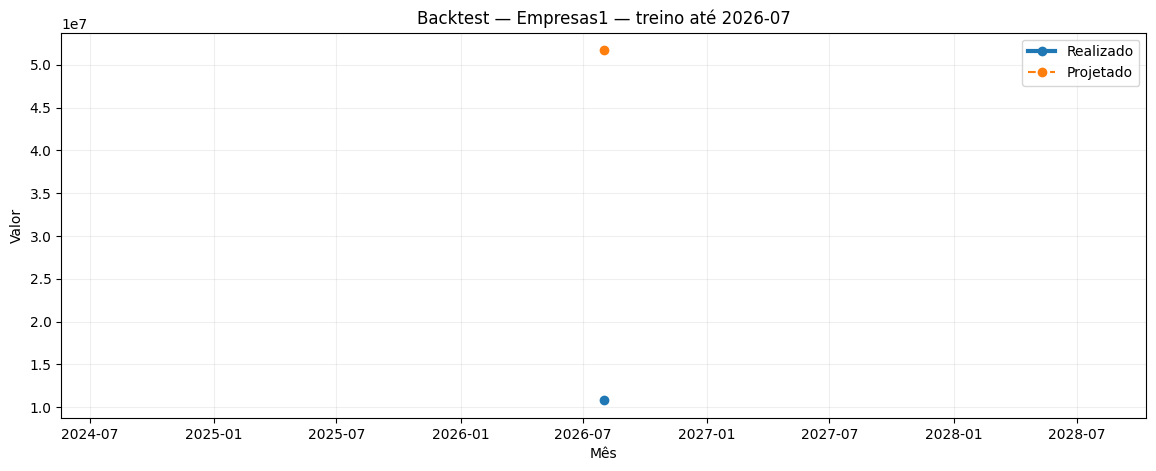

In [22]:

EMPRESA_VALIDACAO = sorted(
    dados[COL_EMPRESA].unique()
)[0]

if not backtest.empty:

    valido = backtest[
        backtest["empresa"]
        == EMPRESA_VALIDACAO
    ].dropna(
        subset=["realizado"]
    )

    if not valido.empty:

        # Corte recente para visualização mais limpa.
        corte_plot = (
            valido["corte_treino"]
            .max()
        )

        g = (
            valido[
                valido["corte_treino"]
                == corte_plot
            ]
            .sort_values("anomes")
        )

        plt.figure(
            figsize=(14, 5)
        )

        plt.plot(
            g["anomes"],
            g["realizado"],
            marker="o",
            linewidth=3,
            label="Realizado"
        )

        plt.plot(
            g["anomes"],
            g["projetado"],
            marker="o",
            linestyle="--",
            label="Projetado"
        )

        plt.title(
            f"Backtest — {EMPRESA_VALIDACAO} "
            f"— treino até {corte_plot:%Y-%m}"
        )

        plt.xlabel("Mês")
        plt.ylabel("Valor")
        plt.grid(alpha=0.2)
        plt.legend()
        plt.show()


## 13. Auditoria da sazonalidade e crescimento

In [23]:

sazonalidade_todas = []

crescimento_todas = []

total_ano_atual_todas = []

for empresa in sorted(
    dados[COL_EMPRESA].unique()
):

    saz = sazonalidade_empresa(
        dados,
        empresa
    ).copy()

    saz["empresa"] = empresa

    sazonalidade_todas.append(
        saz
    )

    crescimento_todas.append({
        "empresa": empresa,
        **crescimento_empresa(
            dados,
            empresa
        )
    })

    total_ano_atual_todas.append({
        "empresa": empresa,
        **estimar_total_ano_atual(
            dados,
            empresa
        )
    })

sazonalidade_df = pd.concat(
    sazonalidade_todas,
    ignore_index=True
)

crescimento_df = pd.DataFrame(
    crescimento_todas
)

total_ano_atual_df = pd.DataFrame(
    total_ano_atual_todas
)

display(sazonalidade_df.head())
display(crescimento_df.head())
display(total_ano_atual_df.head())


,mes,peso_individual,peso_global,peso_empresa_no_blend,peso_sazonal_final,anos_completos_empresa,empresa
0,1,0.0497,0.0732,0.3333,0.0654,1,Empresas1
1,2,0.0502,0.0722,0.3333,0.0649,1,Empresas1
2,3,0.0558,0.0794,0.3333,0.0715,1,Empresas1
3,4,0.0566,0.0789,0.3333,0.0714,1,Empresas1
4,5,0.0684,0.0833,0.3333,0.0783,1,Empresas1


,empresa,crescimento_empresa,crescimento_global,peso_empresa,representatividade_sazonal,representatividade_volume,confianca_estrutural,crescimento_final,crescimento_estrutural_futuro,fator_empresa,ano_comparacao_empresa,volume_base_comparavel,volume_atual_comparavel,volume_tipico_grupo,n_meses_comparaveis,usa_fallback_global,fator_global,ano_comparacao_global,volume_base_global,volume_atual_global,empresas_validas_global
0,Empresas1,1.4514,0.2181,0.6011,0.6011,0.1303,0.0783,0.9595,0.3147,2.4514,"2,026.0000","29,653,375.0000","72,693,061.0000","197,895,204.0000",8,False,1.2181,2026,"3,143,554,037.0000","3,829,129,837.0000",7
1,IAAS,NaN,0.2181,0.0000,0.0000,0.0000,0.0000,0.2181,0.2181,NaN,NaN,NaN,NaN,"197,895,204.0000",0,True,1.2181,2026,"3,143,554,037.0000","3,829,129,837.0000",7
2,Institucionais,NaN,0.2181,0.0000,0.0000,0.0000,0.0000,0.2181,0.2181,NaN,NaN,NaN,NaN,"197,895,204.0000",0,True,1.2181,2026,"3,143,554,037.0000","3,829,129,837.0000",7
3,Itau,0.1964,0.2181,0.6395,0.6395,0.9055,0.5790,0.2042,0.2055,1.1964,"2,026.0000","1,895,629,873.0000","2,267,942,396.0000","197,895,204.0000",8,False,1.2181,2026,"3,143,554,037.0000","3,829,129,837.0000",7
4,Itau BBA,-0.5844,0.2181,0.1735,0.1735,0.0013,0.0002,0.0789,0.2179,0.4156,"2,026.0000","266,055.0000","110,567.0000","197,895,204.0000",2,False,1.2181,2026,"3,143,554,037.0000","3,829,129,837.0000",7


,empresa,ano,total_estimado,realizado_ano,peso_sazonal_observado,total_implicito_sazonal,target_por_crescimento,crescimento_utilizado,ano_anterior_regime_valido
0,Empresas1,2026,"116,841,734.2220","72,693,061.0000",0.6011,"120,924,728.3303","110,687,990.0906",0.9595,True
1,IAAS,2026,61.0101,39.0000,0.6392,61.0101,NaN,0.2181,False
2,Institucionais,2026,"22,626.9105","14,464.0000",0.6392,"22,626.9105",NaN,0.2181,False
3,Itau,2026,"3,553,993,599.0222","2,267,942,396.0000",0.6395,"3,546,580,487.1270","3,567,142,363.2190",0.2042,True
4,Itau BBA,2026,"1,144,772.7166","110,567.0000",0.1735,"637,447.1705","1,251,236.1343",0.0789,True



## Auditoria do crescimento YoY válido

Esta tabela mostra apenas as comparações YoY que passaram pela regra de maturidade do ano-base.

Se uma empresa começou no meio de um ano, você deve perceber que as comparações contra aquele ano parcial não aparecem aqui.


In [24]:

auditoria_yoy = []

for empresa in sorted(dados[COL_EMPRESA].unique()):
    detalhe = detalhes_yoy_serie(
        serie_empresa(dados, empresa)
    )

    if not detalhe.empty:
        detalhe = detalhe.copy()
        detalhe["empresa"] = empresa
        auditoria_yoy.append(detalhe)

auditoria_yoy_df = (
    pd.concat(auditoria_yoy, ignore_index=True)
    if auditoria_yoy
    else pd.DataFrame(
        columns=[
            "data_atual",
            "data_base",
            "ano_atual",
            "ano_base",
            "mes",
            "valor_atual",
            "valor_base",
            "empresa",
        ]
    )
)

# Auditoria resumida do crescimento que efetivamente será usado.
auditoria_crescimento_df = pd.DataFrame([
    {
        "empresa": empresa,
        **crescimento_empresa(dados, empresa)
    }
    for empresa in sorted(dados[COL_EMPRESA].unique())
])

display(auditoria_yoy_df.head(30))
display(auditoria_crescimento_df.head(30))


,data_atual,data_base,ano_atual,ano_base,mes,valor_atual,valor_base,empresa
0,2025-01-01,2024-01-01,2025,2024,1,"2,805,959.0000","72,117.0000",Empresas1
1,2025-02-01,2024-02-01,2025,2024,2,"2,832,938.0000","71,584.0000",Empresas1
2,2025-03-01,2024-03-01,2025,2024,3,"3,150,999.0000","78,954.0000",Empresas1
3,2025-04-01,2024-04-01,2025,2024,4,"3,196,173.0000","83,560.0000",Empresas1
4,2025-05-01,2024-05-01,2025,2024,5,"3,863,066.0000","82,887.0000",Empresas1
5,2025-06-01,2024-06-01,2025,2024,6,"4,059,499.0000","95,674.0000",Empresas1
6,2025-07-01,2024-07-01,2025,2024,7,"4,773,196.0000","377,277.0000",Empresas1
7,2025-08-01,2024-08-01,2025,2024,8,"4,971,545.0000","616,157.0000",Empresas1
8,2025-09-01,2024-09-01,2025,2024,9,"5,317,546.0000","759,379.0000",Empresas1
9,2025-10-01,2024-10-01,2025,2024,10,"6,713,795.0000","1,004,204.0000",Empresas1


,empresa,crescimento_empresa,crescimento_global,peso_empresa,representatividade_sazonal,representatividade_volume,confianca_estrutural,crescimento_final,crescimento_estrutural_futuro,fator_empresa,ano_comparacao_empresa,volume_base_comparavel,volume_atual_comparavel,volume_tipico_grupo,n_meses_comparaveis,usa_fallback_global,fator_global,ano_comparacao_global,volume_base_global,volume_atual_global,empresas_validas_global
0,Empresas1,1.4514,0.2181,0.6011,0.6011,0.1303,0.0783,0.9595,0.3147,2.4514,"2,026.0000","29,653,375.0000","72,693,061.0000","197,895,204.0000",8,False,1.2181,2026,"3,143,554,037.0000","3,829,129,837.0000",7
1,IAAS,NaN,0.2181,0.0000,0.0000,0.0000,0.0000,0.2181,0.2181,NaN,NaN,NaN,NaN,"197,895,204.0000",0,True,1.2181,2026,"3,143,554,037.0000","3,829,129,837.0000",7
2,Institucionais,NaN,0.2181,0.0000,0.0000,0.0000,0.0000,0.2181,0.2181,NaN,NaN,NaN,NaN,"197,895,204.0000",0,True,1.2181,2026,"3,143,554,037.0000","3,829,129,837.0000",7
3,Itau,0.1964,0.2181,0.6395,0.6395,0.9055,0.5790,0.2042,0.2055,1.1964,"2,026.0000","1,895,629,873.0000","2,267,942,396.0000","197,895,204.0000",8,False,1.2181,2026,"3,143,554,037.0000","3,829,129,837.0000",7
4,Itau BBA,-0.5844,0.2181,0.1735,0.1735,0.0013,0.0002,0.0789,0.2179,0.4156,"2,026.0000","266,055.0000","110,567.0000","197,895,204.0000",2,False,1.2181,2026,"3,143,554,037.0000","3,829,129,837.0000",7
5,Itau uniclass,0.1688,0.2181,0.6405,0.6405,0.7217,0.4622,0.1865,0.1953,1.1688,"2,026.0000","513,072,799.0000","599,682,065.0000","197,895,204.0000",8,False,1.2181,2026,"3,143,554,037.0000","3,829,129,837.0000",7
6,OneItau,0.2631,0.2181,0.6334,0.6334,0.7176,0.4546,0.2466,0.2385,1.2631,"2,026.0000","502,822,321.0000","635,100,934.0000","197,895,204.0000",8,False,1.2181,2026,"3,143,554,037.0000","3,829,129,837.0000",7
7,Personalite,0.2551,0.2181,0.6369,0.6369,0.5000,0.3185,0.2417,0.2299,1.2551,"2,026.0000","197,895,204.0000","248,382,270.0000","197,895,204.0000",8,False,1.2181,2026,"3,143,554,037.0000","3,829,129,837.0000",7
8,não identificado,NaN,0.2181,0.0000,0.0000,0.0000,0.0000,0.2181,0.2181,NaN,NaN,NaN,NaN,"197,895,204.0000",0,True,1.2181,2026,"3,143,554,037.0000","3,829,129,837.0000",7
9,private,0.2383,0.2181,0.6358,0.6358,0.0209,0.0133,0.2309,0.2184,1.2383,"2,026.0000","4,214,410.0000","5,218,544.0000","197,895,204.0000",8,False,1.2181,2026,"3,143,554,037.0000","3,829,129,837.0000",7



## Auditoria da mudança de regime

Esta tabela é essencial para validar empresas extremas.

Se uma empresa caiu de milhões para milhares, você deve enxergar:

- `quebra_detectada = True`
- `data_quebra` próxima do início do novo patamar
- `n_observacoes_regime_atual` mostrando quantos meses passaram a ser usados

A projeção de nível/crescimento deve nascer desse trecho atual.


In [25]:

diagnostico_regime_df = pd.DataFrame([
    diagnostico_regime_empresa(dados, empresa)
    for empresa in sorted(dados[COL_EMPRESA].unique())
])

display(diagnostico_regime_df.head(30))


,empresa,quebra_detectada,data_quebra,bic_sem_quebra,bic_com_quebra,n_observacoes_total,n_observacoes_regime_atual,primeiro_mes_regime_atual,ultimo_mes_regime_atual
0,Empresas1,True,2024-08-01,58.7119,-4.1623,37,25,2024-08-01,2026-08-01
1,IAAS,True,2025-10-01,73.1628,51.0621,23,11,2025-10-01,2026-08-01
2,Institucionais,True,2025-06-01,126.1968,3.7147,37,15,2025-06-01,2026-08-01
3,Itau,True,2024-06-01,-89.2074,-101.5488,37,27,2024-06-01,2026-08-01
4,Itau BBA,True,2024-04-01,82.1825,29.4351,31,23,2024-04-01,2026-02-01
5,Itau uniclass,True,2024-06-01,-93.3836,-106.6595,37,27,2024-06-01,2026-08-01
6,OneItau,True,2024-10-01,123.5138,53.7067,31,23,2024-10-01,2026-08-01
7,Personalite,True,2024-10-01,-87.1536,-103.1292,37,23,2024-10-01,2026-08-01
8,não identificado,False,NaT,NaN,NaN,2,2,2025-08-01,2025-09-01
9,private,True,2024-10-01,-88.5368,-104.4346,37,23,2024-10-01,2026-08-01


## 14. Resumo anual projetado

In [26]:

if not forecast_final.empty:

    resumo_anual = (
        forecast_final
        .groupby(
            [
                "empresa",
                "ano_projetado"
            ]
        )
        .agg(
            total_projetado=(
                "projetado",
                "sum"
            ),
            total_anual_modelo=(
                "total_anual_projetado",
                "first"
            ),
            crescimento_modelo=(
                "crescimento_aplicado_ano",
                "first"
            )
        )
        .reset_index()
    )

else:
    resumo_anual = pd.DataFrame()

display(resumo_anual.head(30))


,empresa,ano_projetado,total_projetado,total_anual_modelo,crescimento_modelo
0,Empresas1,2026,"44,148,673.2220","116,841,734.2220",0.9595
1,Empresas1,2027,"135,093,867.4609","6,762,645,870.8971",0.3147
2,IAAS,2026,22.0101,61.0101,0.2181
3,IAAS,2027,65.3565,"6,762,645,870.8971",0.2181
4,Institucionais,2026,"8,162.9105","22,626.9105",0.2181
5,Institucionais,2027,"24,238.8966","6,762,645,870.8971",0.2181
6,Itau,2026,"1,286,051,203.0222","3,553,993,599.0222",0.2042
7,Itau,2027,"3,767,944,746.4178","6,762,645,870.8971",0.2055
8,Itau BBA,2026,"1,034,205.7166","1,144,772.7166",0.0789
9,Itau BBA,2027,"1,226,140.4481","6,762,645,870.8971",0.2179


## 15. Formatação dos Excels

In [27]:

def formatar_excel(caminho):
    from openpyxl import load_workbook
    from openpyxl.styles import (
        Font,
        PatternFill,
        Alignment
    )

    wb = load_workbook(caminho)

    for ws in wb.worksheets:

        ws.freeze_panes = "A2"

        if ws.max_row >= 1:
            ws.auto_filter.ref = ws.dimensions

        for cell in ws[1]:
            cell.font = Font(
                bold=True,
                color="FFFFFF"
            )

            cell.fill = PatternFill(
                "solid",
                fgColor="1F4E78"
            )

            cell.alignment = Alignment(
                horizontal="center"
            )

        for col in ws.columns:
            max_len = 0
            letra = col[0].column_letter

            for cell in col[:500]:
                if cell.value is not None:
                    max_len = max(
                        max_len,
                        len(str(cell.value))
                    )

            ws.column_dimensions[
                letra
            ].width = min(
                max(
                    max_len + 2,
                    11
                ),
                32
            )

    wb.save(caminho)



## 16. Excel do backtest — treino x realizado

Esse arquivo serve para validar o modelo antes de confiar na projeção futura.


In [28]:

if not backtest.empty:

    # Resumo dos dados que existiam em cada corte.
    treino_resumo = []

    for corte in CORTES_BACKTEST:

        base_treino = dados[
            dados[COL_DATA] <= corte
        ]

        treino_resumo.append({
            "corte_treino": corte,
            "inicio_treino": (
                base_treino[COL_DATA]
                .min()
            ),
            "fim_treino": (
                base_treino[COL_DATA]
                .max()
            ),
            "linhas_treino": len(
                base_treino
            ),
            "empresas_treino": (
                base_treino[
                    COL_EMPRESA
                ].nunique()
            )
        })

    treino_resumo = pd.DataFrame(
        treino_resumo
    )

    with pd.ExcelWriter(
        ARQUIVO_BACKTEST,
        engine="openpyxl"
    ) as writer:

        treino_resumo.to_excel(
            writer,
            sheet_name="treino_resumo",
            index=False
        )

        backtest.to_excel(
            writer,
            sheet_name="realizado_vs_projetado",
            index=False
        )

        metricas_gerais.to_excel(
            writer,
            sheet_name="metricas_gerais",
            index=False
        )

        metricas_empresa.to_excel(
            writer,
            sheet_name="metricas_empresa",
            index=False
        )

        metricas_horizonte.to_excel(
            writer,
            sheet_name="metricas_horizonte",
            index=False
        )

        metricas_corte.to_excel(
            writer,
            sheet_name="metricas_corte",
            index=False
        )

    formatar_excel(
        ARQUIVO_BACKTEST
    )

    print(
        "Excel do backtest gerado:",
        ARQUIVO_BACKTEST
    )

else:
    print(
        "Backtest não exportado: "
        "histórico insuficiente."
    )


Excel do backtest gerado: backtest_treino_realizado.xlsx


## 17. Excel final — realizado + projetado

In [30]:

with pd.ExcelWriter(
    ARQUIVO_SAIDA,
    engine="openpyxl"
) as writer:

    realizado_projetado.to_excel(
        writer,
        sheet_name="realizado_projetado",
        index=False
    )

    forecast_final.to_excel(
        writer,
        sheet_name="forecast_detalhado",
        index=False
    )

    resumo_anual.to_excel(
        writer,
        sheet_name="resumo_anual",
        index=False
    )

    sazonalidade_df.to_excel(
        writer,
        sheet_name="sazonalidade",
        index=False
    )

    crescimento_df.to_excel(
        writer,
        sheet_name="crescimento",
        index=False
    )

    total_ano_atual_df.to_excel(
        writer,
        sheet_name="estimativa_ano_atual",
        index=False
    )

    diagnostico_crescimento_2027.to_excel(
        writer,
        sheet_name="crescimento_2027",
        index=False
    )

    incrementos_ancora_df.to_excel(
        writer,
        sheet_name="ancora_incrementos",
        index=False
    )

    pd.DataFrame(
        [diagnostico_ancora]
    ).to_excel(
        writer,
        sheet_name="ancora_resumo",
        index=False
    )

    if not metricas_gerais.empty:
        metricas_gerais.to_excel(
            writer,
            sheet_name="backtest_resumo",
            index=False
        )

formatar_excel(
    ARQUIVO_SAIDA
)

print(
    "Excel final gerado:",
    ARQUIVO_SAIDA
)


Excel final gerado: resultado_forecast_sazonal.xlsx



# Como interpretar o resultado

## `realizado_projetado`

É a aba principal para consumo do forecast.

Ela contém:

- `realizado`: valor histórico;
- `projetado`: valor futuro;
- `valor_final`: realizado quando existe, senão projetado;
- `tipo`: Realizado ou Projetado.

---

## `resumo_anual`

Mostra o total projetado por empresa e ano.

Essa aba é importante para verificar rapidamente se 2027 está coerente.

Se o crescimento da empresa for 8%, por exemplo, o total de 2027 deve ficar aproximadamente 8% acima do total anual utilizado como base.

---

## `sazonalidade`

Mostra:

- participação mensal individual;
- participação mensal global;
- peso dado à empresa;
- participação sazonal final.

Os 12 `peso_sazonal_final` de uma empresa somam 100%.

---

## `crescimento`

Mostra:

- crescimento YoY típico da empresa;
- crescimento YoY do grupo;
- peso dado à empresa;
- crescimento final utilizado.

Não existe teto manual de crescimento.

A proteção vem da:

- mediana;
- comparação com o mesmo mês do ano anterior;
- combinação empresa + grupo;
- separação entre crescimento anual e sazonalidade mensal.

---

## `estimativa_ano_atual`

Ajuda a entender como o total do ano corrente foi estimado.

Você consegue comparar:

- realizado acumulado;
- quanto do ano sazonalmente já passou;
- total implícito pela sazonalidade;
- target baseado no crescimento;
- total anual final utilizado.

---

# O principal cuidado

Se uma empresa mudou estruturalmente — por exemplo, aquisição, lançamento ou encerramento — o histórico pode deixar de representar o futuro.

Nesse caso, não é necessariamente um erro matemático do modelo.

É uma mudança de regime do negócio.

Por isso sempre olhe:

```text
Backtest
+
BIAS
+
WMAPE
+
Resumo anual
```

antes de publicar a projeção.



# Checklist para validar os dois problemas

Depois de rodar o notebook, abra a aba `auditoria_crescimento`.

## Caso 1 — crescimento do grupo

Olhe:

```text
volume_base_global
volume_atual_global
fator_global
crescimento_global
```

Você deve conseguir reproduzir:

```excel
=Volume_Atual_Global / Volume_Base_Global - 1
```

Não existe média simples entre as empresas.

## Caso 2 — empresa que caiu de milhões para milhares

Olhe:

```text
volume_base_comparavel
volume_atual_comparavel
fator_empresa
representatividade_sazonal
crescimento_final
```

Depois abra `estimativa_ano_atual` e verifique:

```text
realizado_ano
peso_sazonal_observado
total_implicito_sazonal
target_por_crescimento
total_estimado
```

Para uma empresa cujo nível atual caiu brutalmente, o campo
`total_implicito_sazonal` deve cair junto.

Isso é proposital.

O modelo ainda aprende a FORMA histórica da sazonalidade,
mas o nível monetário/transacional fica ancorado no regime atual.

## Sinal de alerta

Se `total_implicito_sazonal` continuar milhões enquanto o realizado corrente
é de apenas milhares, verifique a aba `sazonalidade`.

Normalmente isso significaria que os meses realizados representam uma parcela
sazonal extremamente pequena do ano. Nesse caso vale conferir se houve uma
mudança estrutural de calendário/operação que o histórico antigo já não representa.



# Como validar manualmente uma empresa que mudou de regime

Pegue uma empresa problemática e faça no Excel:

## 1. Observe a série em ordem mensal

Exemplo:

```text
Jan/2025 = 41.099.520
Fev/2025 = 30.124.257
...
Jun/2025 =    222.396
Jul/2025 =      2.009
Ago/2025 =      2.095
...
Ago/2026 =      1.471
```

Visualmente já existe uma ruptura de nível.

## 2. O notebook detecta essa ruptura automaticamente

A aba:

```text
diagnostico_regime
```

mostra o ponto escolhido.

## 3. Depois do corte, refaça a lógica somente com o regime atual

Por exemplo:

```text
Jul/2025 até Ago/2026
```

Agora calcule:

```excel
Média do nível atual
Mediana
YoY pós-quebra
Pesos sazonais válidos
```

O forecast pode continuar usando a forma sazonal do grupo caso ainda falte histórico,
mas o TOTAL anual deve ficar coerente com o nível de alguns milhares.

## 4. O que não pode acontecer

Se o realizado corrente está perto de 2 mil/mês e o total anual projetado volta para milhões,
isso significa que algum componente pré-quebra ainda está contaminando o nível.

A aba `diagnostico_regime` serve justamente para verificar isso.



# O que mudou matematicamente

Antes, mesmo depois de detectar uma quebra, ainda podia acontecer:

```text
2025 total = 136.797.405
crescimento final = -X%
target 2026 = 2025 total × (1 - X%)
```

Isso trazia o regime antigo de volta.

Agora:

```text
se 2025 não possui os 12 meses dentro do regime atual
→ 2025 não é aceito como base anual
```

Logo:

```text
Total 2026 =
Realizado Jan–Ago/2026
/
Participação sazonal Jan–Ago
```

Se Jan–Ago realizados somarem aproximadamente 14,5 mil e representarem,
por exemplo, 65% do ano:

```text
14.500 / 65% ≈ 22.300
```

É essa ordem de grandeza que deve alimentar o restante de 2026 e depois 2027.

A aba `diagnostico_nivel` foi criada justamente para conferir essa conta antes de olhar o forecast mensal.



# O que mudou em relação à versão anterior

O modelo anterior usava o mesmo `crescimento_final` para:

```text
completar o ano corrente
e
crescer o ano seguinte
```

Agora existem dois conceitos:

### `crescimento_final`

É o crescimento mais próximo do observado e continua sendo usado para ajudar a estimar o ano corrente.

### `crescimento_estrutural_futuro`

É usado para o ano seguinte.

Ele exige simultaneamente:

- boa cobertura sazonal dos meses comparados;
- volume economicamente representativo.

Caso contrário, converge para o crescimento global ponderado por volume.

Isso mantém 2026 próximo do que os dados recentes estão mostrando,
mas evita extrapolar com a mesma agressividade para 2027.

## Regra prática para validar no Excel

Escolha uma empresa e reconstrua:

```excel
Rep_Volume =
Volume_Base_Comparavel /
(Volume_Base_Comparavel + Volume_Tipico_Grupo)

Confianca =
Rep_Sazonal * Rep_Volume

Cresc_2027 =
Confianca*Cresc_Empresa
+(1-Confianca)*Cresc_Grupo
```

Depois:

```excel
Total_2027 =
Total_2026_Estimado * (1 + Cresc_2027)
```

E finalmente distribua esse total pelos 12 pesos sazonais.



# Como validar a âncora manualmente no Excel

Imagine os seguintes incrementos anuais do portfólio:

```text
2025 - 2024 = 830.160.412
2026 - 2025 = 989.014.906
```

No Excel:

```excel
=MEDIANA(830160412;989014906)
```

Resultado:

```text
909.587.659
```

Se o total estimado de 2026 for `T2026`:

```excel
Total_2027_Alvo
=
T2026 + 909587659
```

Agora compare com o forecast bruto do modelo:

```excel
Fator_Ajuste
=
Total_2027_Alvo
/
Total_2027_Bruto
```

Cada valor mensal/empresa de 2027 é:

```excel
Forecast_Ajustado
=
Forecast_Bruto
* Fator_Ajuste
```

Portanto:

- a sazonalidade continua igual;
- a participação relativa das empresas continua igual;
- somente o tamanho agregado de 2027 é suavizado.

A aba `ancora_incrementos` mostra os incrementos usados.
A aba `ancora_resumo` mostra o total bruto, total-alvo e fator final de ajuste.
